# PD Model Train

In [1]:
import numpy as np
import pandas as pd

In [2]:
df_input_prep = pd.read_pickle('/Users/eileending/Downloads/input_train.pkl')
df_target_prep = pd.read_pickle('/Users/eileending/Downloads/target_train.pkl')
#df_input_prep = pd.read_pickle('/Users/eileending/Downloads/input_test.pkl')
#df_target_prep = pd.read_pickle('/Users/eileending/Downloads/target_test.pkl')

In [3]:
df1 = pd.concat([df_input_prep['grade'],df_target_prep], axis=1)

In [4]:
# % of good borrowers
df_grade = pd.concat([df1.groupby(df1.columns.values[0],as_index = False)[df1.columns.values[1]].count(), 
                      df1.groupby(df1.columns.values[0],as_index = False)[df1.columns.values[1]].mean()],axis=1)

In [5]:
df_grade = df_grade.iloc[:,[0,1,3]]

In [6]:
df_grade.columns = [df_grade.columns.values[0],'n_obs','prop_good']

In [7]:
df_grade['prop_n_obs'] = df_grade['n_obs']/df_grade['n_obs'].sum()
df_grade

,grade,n_obs,prop_good,prop_n_obs
0,A,59759,0.961044,0.160200
1,B,109730,0.921015,0.294160
2,C,100245,0.885770,0.268733
3,D,61498,0.846304,0.164862
4,E,28612,0.805257,0.076702
5,F,10530,0.754416,0.028228
6,G,2654,0.727958,0.007115


In [8]:
df_grade['n_good'] = df_grade['prop_good']*df_grade['n_obs']
df_grade['n_bad'] = (1-df_grade['prop_good'])*df_grade['n_obs']
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0
1,B,109730,0.921015,0.294160,101063.0,8667.0
2,C,100245,0.885770,0.268733,88794.0,11451.0
3,D,61498,0.846304,0.164862,52046.0,9452.0
4,E,28612,0.805257,0.076702,23040.0,5572.0
5,F,10530,0.754416,0.028228,7944.0,2586.0
6,G,2654,0.727958,0.007115,1932.0,722.0


In [9]:
df_grade['prop_n_good'] = df_grade['n_good']/df_grade['n_good'].sum()
df_grade['prop_n_bad'] = df_grade['n_bad']/df_grade['n_bad'].sum()
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706


In [10]:
df_grade['WoE'] = np.log(df_grade['prop_n_good']/df_grade['prop_n_bad'])
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459


In [11]:
df_grade['IV'] = ((df_grade['prop_n_good']-df_grade['prop_n_bad']) * df_grade['WoE']).sum()

In [12]:
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.288636
1,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.288636
2,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.288636
4,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.288636
5,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.288636
6,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,0.288636


In [13]:
# automate for all categorical variables (Macro)

In [14]:
def woe_cal(df, disc_var_name, good_bad_var_df):
    df = pd.concat([df[disc_var_name],good_bad_var_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(), 
                      df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns = [df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs'] = df['n_obs']/df['n_obs'].sum()
    df['n_good'] = df['prop_good']*df['n_obs']
    df['n_bad'] = (1-df['prop_good'])*df['n_obs']
    df['prop_n_good'] = df['n_good']/df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad']/df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good']/df['prop_n_bad'])
    df['IV'] = ((df['prop_n_good']-df['prop_n_bad']) * df['WoE']).sum()
    return df

In [15]:
df_sub_grade = woe_cal(df_input_prep, 'sub_grade', df_target_prep)
df_homeown = woe_cal(df_input_prep, 'home_ownership', df_target_prep)
df_verif_sts = woe_cal(df_input_prep, 'verification_status', df_target_prep)
df_addr_state = woe_cal(df_input_prep, 'addr_state', df_target_prep)
df_ini_sts = woe_cal(df_input_prep, 'initial_list_status', df_target_prep)

# Visulization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [17]:
def plot_by_woe(df_WoE, rotation_of_x_axis=0):
    x = np.array(df_WoE.iloc[:,0].apply(str))
    y = df_WoE['WoE']
    plt.figure(figsize=(18,6))
    plt.plot(x,y,marker='o',linestyle = '--',color='k')
    plt.xlabel(df_WoE.columns[0])
    plt.title(str('WoE by '+ df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis)

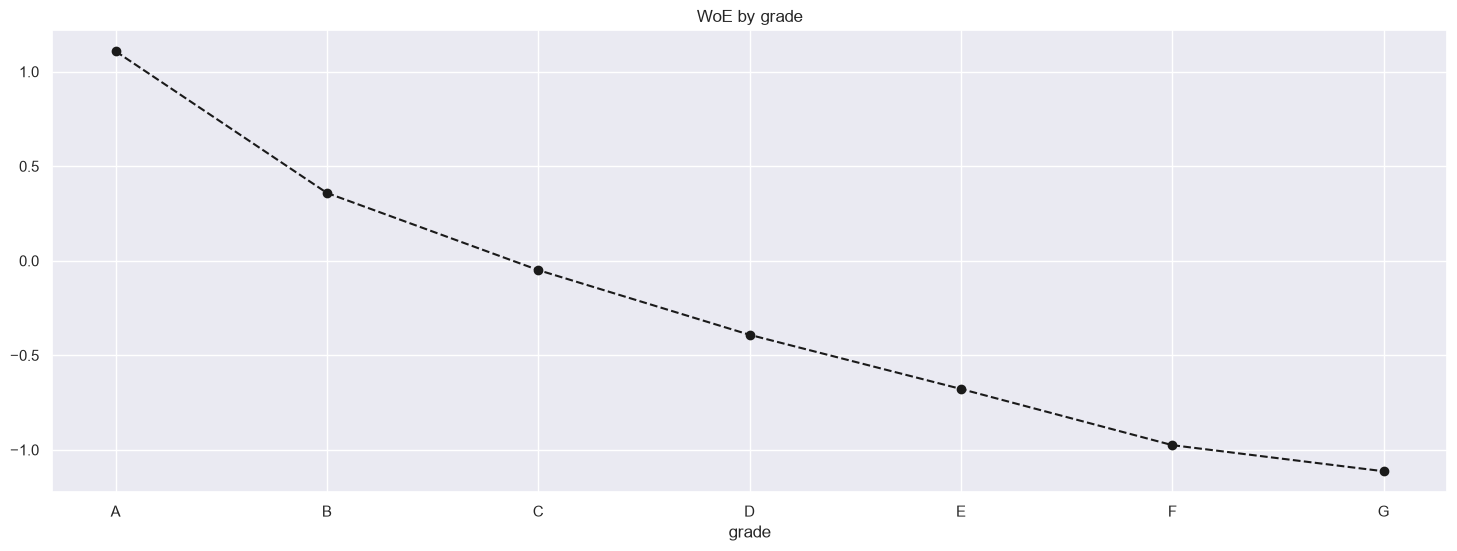

In [18]:

# Analyze the plot and data one by one
# 1. grade 
plot_by_woe(df_grade)
# reference grade_G, grade_A to grade_F used as independent variable

In [19]:
# 2. Home Owner 
df_homeown
# 'Any' has only 1, 'None' and 'Other' are very few, combine them all with 'Rent' (smallest group), with higher default rate

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,ANY,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
1,MORTGAGE,188956,0.903835,0.506546,170785.0,18171.0,0.514026,0.445608,0.142834,inf
2,NONE,40,0.850000,0.000107,34.0,6.0,0.000102,0.000147,-0.363144,inf
3,OTHER,137,0.795620,0.000367,109.0,28.0,0.000328,0.000687,-0.738602,inf
4,OWN,33295,0.892536,0.089256,29717.0,3578.0,0.089442,0.087743,0.019170,inf
5,RENT,150599,0.873870,0.403720,131604.0,18995.0,0.396099,0.465815,-0.162123,inf


In [20]:
df_input_prep['home_ownership_RONA'] = df_input_prep[['home_ownership_RENT','home_ownership_ANY',
                                                     'home_ownership_NONE','home_ownership_OTHER']].sum(axis=1)

In [21]:
x = df_input_prep['home_ownership_RONA'].sum()

print(x)

150777


In [22]:
# 3. addr_state
df_input_prep['addr_state'].unique()

<StringArray>
['SC', 'NJ', 'GA', 'MA', 'CA', 'IL', 'NC', 'NY', 'TX', 'CT', 'FL', 'VA', 'UT',
 'AZ', 'MD', 'WI', 'MI', 'CO', 'TN', 'IN', 'AL', 'NV', 'MT', 'RI', 'OR', 'MN',
 'KS', 'AK', 'PA', 'OH', 'WA', 'KY', 'OK', 'MO', 'NM', 'HI', 'WV', 'LA', 'VT',
 'AR', 'DC', 'SD', 'NH', 'WY', 'MS', 'DE', 'IA', 'NE', 'ID', 'ME']
Length: 50, dtype: str

In [23]:
if 'addr_state_ND' in df_input_prep.columns.values:
    pass
else:
    df_input_prep['addr_state_ND'] = 0
# redo the WoE with the newly added ND
df_addr_state = woe_cal(df_input_prep, 'addr_state', df_target_prep)

In [24]:
df_addr_state = df_addr_state.sort_values('WoE').reset_index(drop=True)
df_addr_state

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,NE,13,0.461538,0.000035,6.0,7.0,0.000018,0.000172,-2.251896,inf
1,IA,13,0.769231,0.000035,10.0,3.0,0.000030,0.000074,-0.893772,inf
2,NV,5221,0.864585,0.013996,4514.0,707.0,0.013586,0.017338,-0.243837,inf
3,FL,25211,0.875808,0.067585,22080.0,3131.0,0.066456,0.076782,-0.144425,inf
4,HI,2001,0.877061,0.005364,1755.0,246.0,0.005282,0.006033,-0.132852,inf
5,AL,4671,0.877328,0.012522,4098.0,573.0,0.012334,0.014052,-0.130376,inf
6,NM,2075,0.883373,0.005563,1833.0,242.0,0.005517,0.005935,-0.072973,inf
7,VA,11366,0.883864,0.030470,10046.0,1320.0,0.030236,0.032370,-0.068202,inf
8,NY,32211,0.883984,0.086350,28474.0,3737.0,0.085701,0.091643,-0.067037,inf
9,OK,3284,0.884287,0.008804,2904.0,380.0,0.008740,0.009319,-0.064072,inf


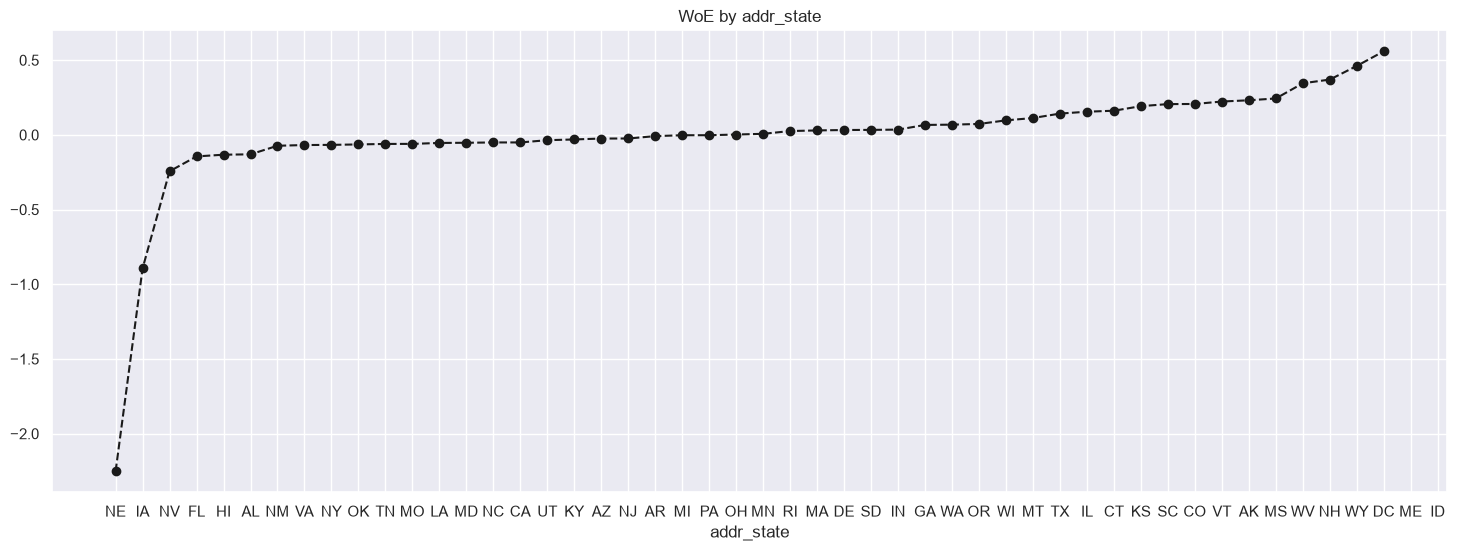

In [25]:
plot_by_woe(df_addr_state)

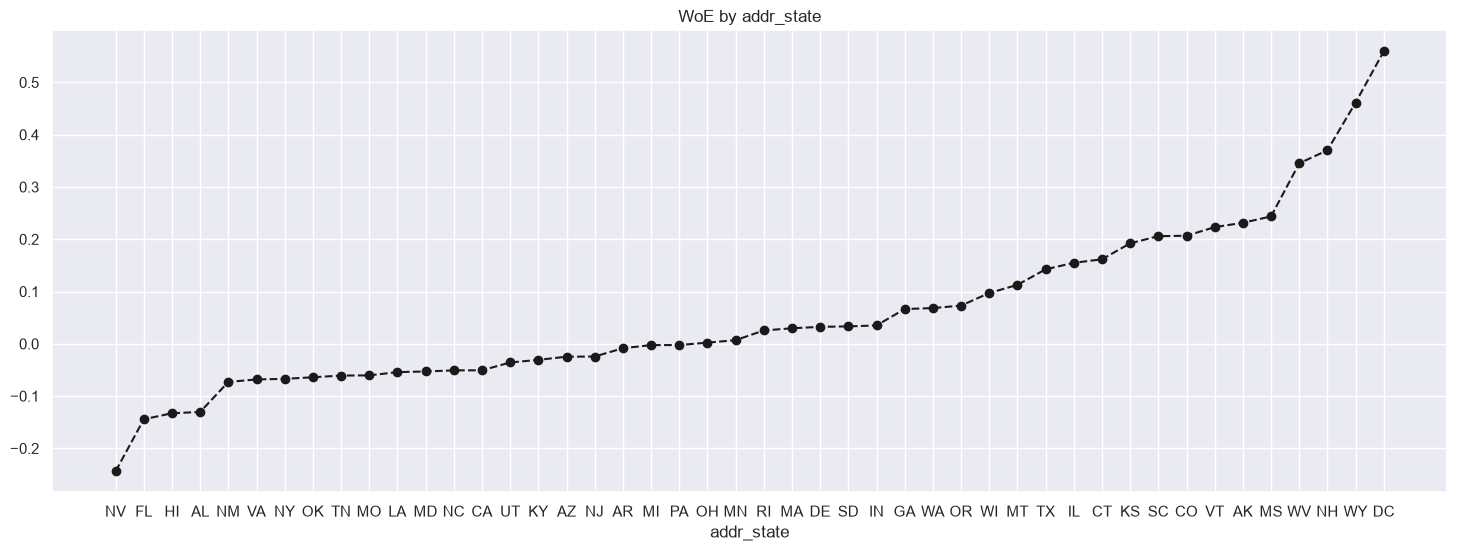

In [26]:
plot_by_woe(df_addr_state.iloc[2: -2, :])

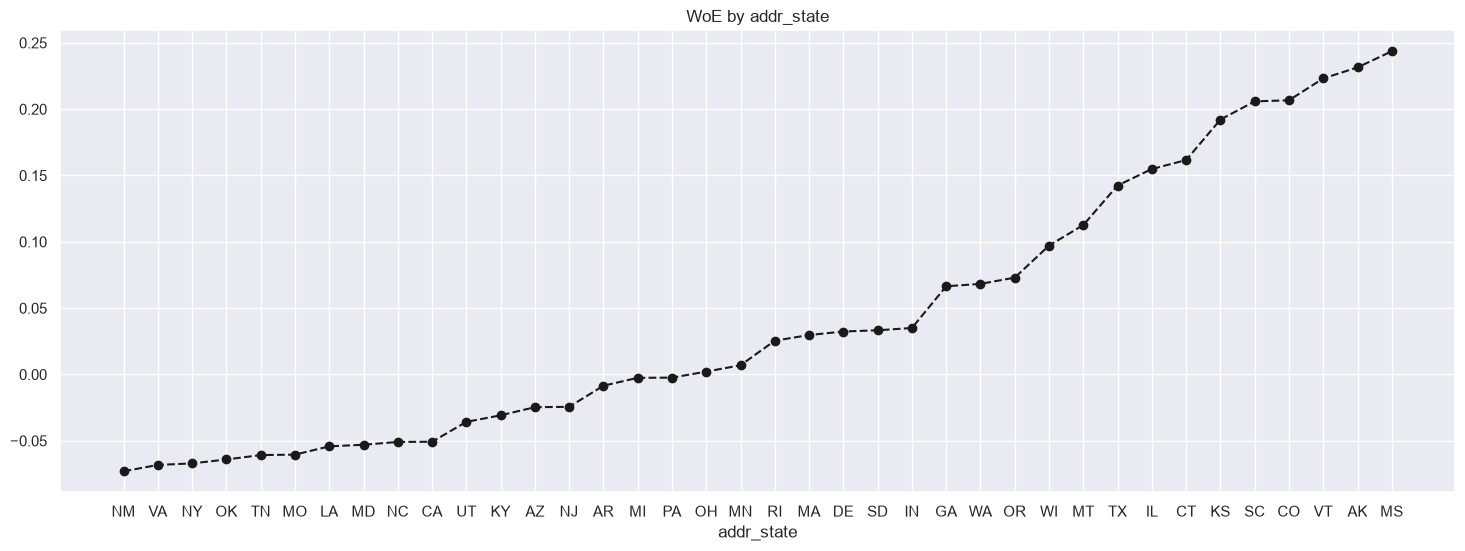

In [27]:
# group the first 6 and last 6 by both number of obs and WoE based on the plot and the data
plot_by_woe(df_addr_state.iloc[6: -6, :])

In [28]:
# group further still by number of observation and WoE
# NY and CA having many observations, thus (6,2, NY, 6, CA, 4,5,5,3,2,TX,2,6,6(1 more of the not existing)) 
recategory = ['ND_NE_IA_NV_FL_HI_AL','NM_VA','NY','OK_TN_MO_LA_MD_NC','CA','UT_KY_AZ_NJ','AR_MI_PA_OH_MN','RI_MA_DE_SD_IN',
        'GA_WA_OR', 'WI_MT','TX','IL_CT','KS_SC_CO_VT_AK_MS','WV_NH_WY_DC_ME_ID']
df_input_prep['addr_state_ND_NE_IA_NV_FL_HI_AL'] = df_input_prep[['addr_state_ND','addr_state_NE','addr_state_IA','addr_state_NV','addr_state_FL',
    'addr_state_HI','addr_state_AL']].sum(axis=1)
df_input_prep['addr_state_NM_VA'] = df_input_prep[['addr_state_NM','addr_state_VA']].sum(axis=1)
df_input_prep['addr_state_OK_TN_MO_LA_MD_NC'] = df_input_prep[['addr_state_OK','addr_state_TN','addr_state_MO','addr_state_LA','addr_state_MD','addr_state_NC']].sum(axis=1)
df_input_prep['addr_state_UT_KY_AZ_NJ'] = df_input_prep[['addr_state_UT','addr_state_KY','addr_state_AZ','addr_state_NJ']].sum(axis=1)
df_input_prep['addr_state_AR_MI_PA_OH_MN'] = df_input_prep[['addr_state_AR','addr_state_MI','addr_state_PA','addr_state_OH','addr_state_MN']].sum(axis=1)
df_input_prep['addr_state_RI_MA_DE_SD_IN'] = df_input_prep[['addr_state_RI','addr_state_MA','addr_state_DE','addr_state_SD','addr_state_IN']].sum(axis=1)
df_input_prep['addr_state_GA_WA_OR'] = df_input_prep[['addr_state_GA','addr_state_WA','addr_state_OR']].sum(axis=1)
df_input_prep['addr_state_WI_MT'] = df_input_prep[['addr_state_WI','addr_state_MT']].sum(axis=1)
df_input_prep['addr_state_IL_CT'] = df_input_prep[['addr_state_IL','addr_state_CT']].sum(axis=1)
df_input_prep['addr_state_KS_SC_CO_VT_AK_MS'] = df_input_prep[['addr_state_KS','addr_state_SC','addr_state_CO','addr_state_VT','addr_state_AK','addr_state_MS']].sum(axis=1)
df_input_prep['addr_state_WV_NH_WY_DC_ME_ID'] = df_input_prep[['addr_state_WV','addr_state_NH','addr_state_WY','addr_state_DC','addr_state_ME','addr_state_ID']].sum(axis=1)


In [29]:
# homework variables: 

# 4. verification status
df_input_prep['verification_status'].unique()
# only 3, no need to further classify

<StringArray>
['Source Verified', 'Not Verified', 'Verified']
Length: 3, dtype: str

In [30]:
df_verif_sts = df_verif_sts.sort_values('WoE').reset_index(drop=True)
df_verif_sts

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,Verified,134414,0.872781,0.360332,117314.0,17100.0,0.353090,0.419344,-0.171969,0.020384
1,Source Verified,120030,0.895918,0.321772,107537.0,12493.0,0.323663,0.306366,0.054922,0.020384
2,Not Verified,118584,0.905679,0.317896,107399.0,11185.0,0.323248,0.274290,0.164232,0.020384


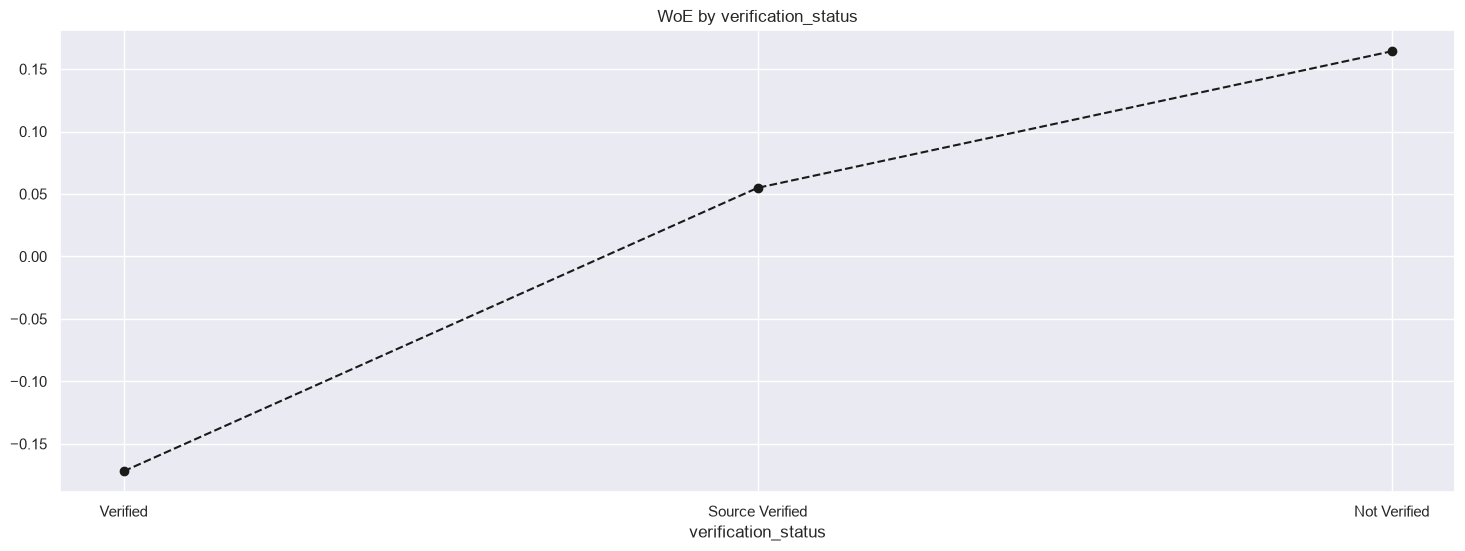

In [31]:
plot_by_woe(df_verif_sts)
# almost same n_obs, so use Verified as reference

In [32]:
# 5 initial list status
df_ini_sts = df_ini_sts.sort_values('WoE').reset_index(drop=True)
df_ini_sts
# based on WoE and n_obs, 'initial_status_w' as reference

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,f,242514,0.879694,0.650123,213338.0,29176.0,0.642101,0.715484,-0.108214,0.02478
1,w,130514,0.911105,0.349877,118912.0,11602.0,0.357899,0.284516,0.229461,0.02478


In [33]:
# 6 Purpose
df_purpose = woe_cal(df_input_prep, 'purpose', df_target_prep)
df_purpose = df_purpose.sort_values('WoE').reset_index(drop=True)
df_purpose

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,small_business,5582,0.786098,0.014964,4388.0,1194.0,0.013207,0.029280,-0.796180,0.035418
1,educational,333,0.801802,0.000893,267.0,66.0,0.000804,0.001619,-0.700151,0.035418
2,moving,2392,0.839465,0.006412,2008.0,384.0,0.006044,0.009417,-0.443493,0.035418
3,house,1830,0.860109,0.004906,1574.0,256.0,0.004737,0.006278,-0.281547,0.035418
4,other,18884,0.862264,0.050624,16283.0,2601.0,0.049008,0.063784,-0.263519,0.035418
5,renewable_energy,281,0.864769,0.000753,243.0,38.0,0.000731,0.000932,-0.242270,0.035418
6,medical,3684,0.868350,0.009876,3199.0,485.0,0.009628,0.011894,-0.211300,0.035418
7,wedding,1887,0.881823,0.005059,1664.0,223.0,0.005008,0.005469,-0.087937,0.035418
8,vacation,1991,0.882471,0.005337,1757.0,234.0,0.005288,0.005738,-0.081703,0.035418
9,debt_consolidation,219183,0.886884,0.587578,194390.0,24793.0,0.585071,0.607999,-0.038440,0.035418


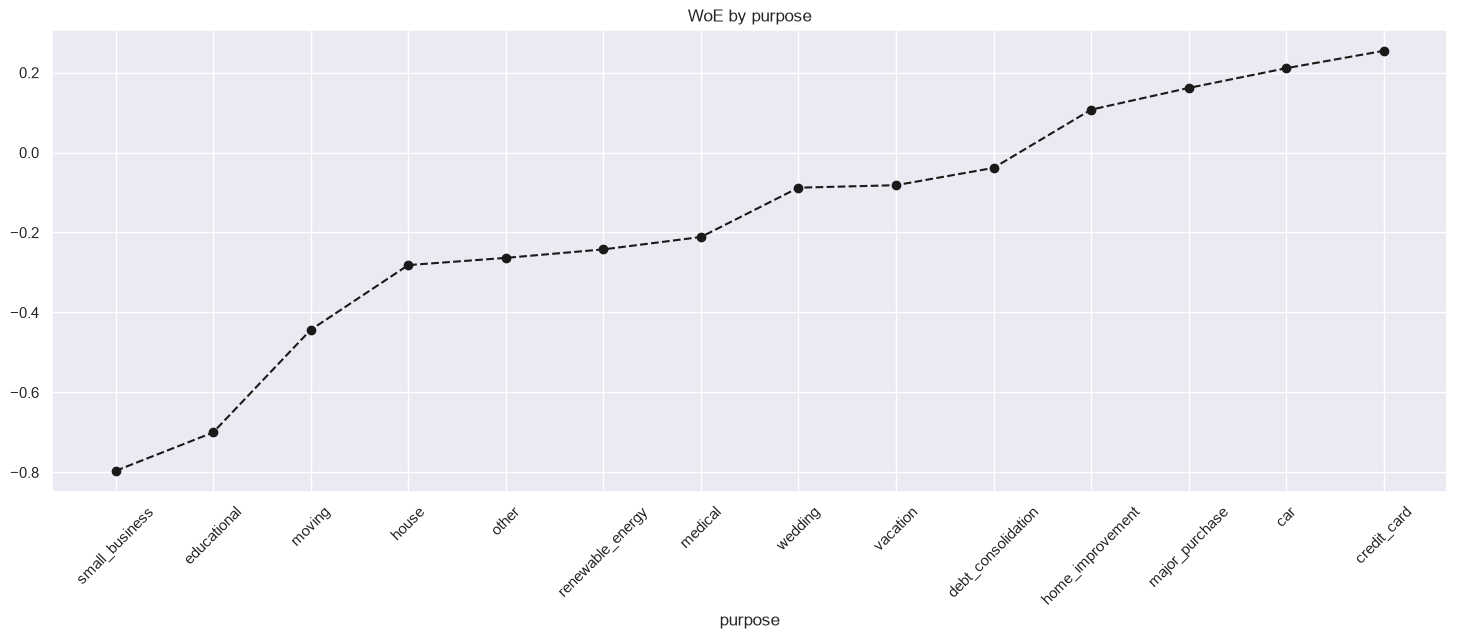

In [34]:
plot_by_woe(df_purpose, 45)

In [35]:
# debt_consolidation(219K), credit_card(83K), then home_improvement(21K),other(18K)
recategory = ['small_business+educational', 'moving+house+other+renewable_energy+medical', 
              'wedding+vacation','debt_consolidation','home_improvement+major_purchase+car','credit_card']
df_input_prep['purpose_sb_ed'] = df_input_prep[['purpose_small_business', 'purpose_educational']].sum(axis=1)
df_input_prep['purpose_other_mhrm'] = df_input_prep[['purpose_moving', 'purpose_house','purpose_other',
    'purpose_renewable_energy','purpose_medical']].sum(axis=1)
df_input_prep['purpose_wed_vac'] = df_input_prep[['purpose_wedding', 'purpose_vacation']].sum(axis=1)
df_input_prep['purpose_imp_maj+car'] = df_input_prep[['purpose_home_improvement','purpose_major_purchase','purpose_car']].sum(axis=1)

In [36]:
# Back to Course 
# Coutinous Numbers 

In [37]:
def woe_conti(df, disc_var_name, good_bad_var_df):
    df = pd.concat([df[disc_var_name],good_bad_var_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(), 
                      df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns = [df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs'] = df['n_obs']/df['n_obs'].sum()
    df['n_good'] = df['prop_good']*df['n_obs']
    df['n_bad'] = (1-df['prop_good'])*df['n_obs']
    df['prop_n_good'] = df['n_good']/df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad']/df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good']/df['prop_n_bad'])
    df['IV'] = ((df['prop_n_good']-df['prop_n_bad']) * df['WoE']).sum()
    return df

In [38]:
# 7 term length
df_input_prep['term_int'].unique()

<IntegerArray>
[36, 60]
Length: 2, dtype: Int64

In [39]:
df_term = woe_conti(df_input_prep, 'term_int', df_target_prep)
df_term

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,36,270419,0.902995,0.724929,244187.0,26232.0,0.73495,0.643288,0.133209,0.039434
1,60,102609,0.858239,0.275071,88063.0,14546.0,0.26505,0.356712,-0.297009,0.039434


In [40]:
df_input_prep['term_36'] = np.where((df_input_prep['term_int']==36),1,0)
df_input_prep['term_60'] = np.where((df_input_prep['term_int']==60),1,0)

In [41]:
# 8 employment length
df_emp_length= woe_conti(df_input_prep, 'emp_length_int', df_target_prep)
df_emp_length


,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,45720,0.876400,0.122565,40069.0,5651.0,0.120599,0.138580,-0.138975,0.006506
1,1.0,23654,0.886996,0.063411,20981.0,2673.0,0.063148,0.065550,-0.037329,0.006506
2,2.0,33078,0.890955,0.088674,29471.0,3607.0,0.088701,0.088455,0.002785,0.006506
3,3.0,29205,0.890772,0.078292,26015.0,3190.0,0.078299,0.078228,0.000907,0.006506
4,4.0,22468,0.890644,0.060231,20011.0,2457.0,0.060229,0.060253,-0.000404,0.006506
5,5.0,24602,0.884725,0.065952,21766.0,2836.0,0.065511,0.069547,-0.059790,0.006506
6,6.0,20887,0.883899,0.055993,18462.0,2425.0,0.055567,0.059468,-0.067862,0.006506
7,7.0,21049,0.887453,0.056427,18680.0,2369.0,0.056223,0.058095,-0.032759,0.006506
8,8.0,17853,0.889878,0.047860,15887.0,1966.0,0.047816,0.048212,-0.008245,0.006506
9,9.0,14267,0.886662,0.038246,12650.0,1617.0,0.038074,0.039654,-0.040660,0.006506


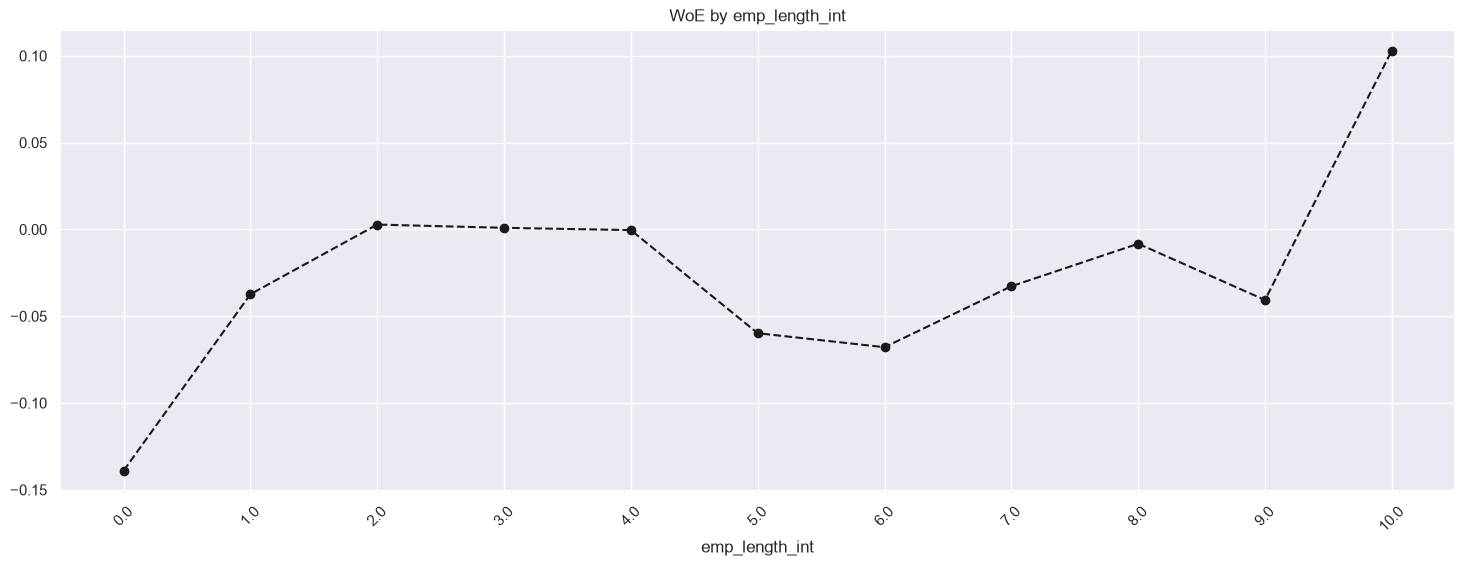

In [42]:
plot_by_woe(df_emp_length, 45)

In [43]:
df_input_prep['emp_length_0'] = np.where(df_input_prep['emp_length_int'].isin([0]),1,0)
df_input_prep['emp_length_1'] = np.where(df_input_prep['emp_length_int'].isin([1]),1,0)
df_input_prep['emp_length_2-4'] = np.where(df_input_prep['emp_length_int'].isin(range(2,5)),1,0)
df_input_prep['emp_length_5-6'] = np.where(df_input_prep['emp_length_int'].isin(range(5,7)),1,0)
df_input_prep['emp_length_7-9'] = np.where(df_input_prep['emp_length_int'].isin(range(7,10)),1,0)
df_input_prep['emp_length_10'] = np.where(df_input_prep['emp_length_int'].isin([10]),1,0)

In [44]:
# 9 month since issue date
df_input_prep['mths_since_issued'].unique()
# as there are around 90, cut into 50?  
# what about the smaller slices? as we have to regroup anayway? for example, cut into 30? 

array([ 45.,  64.,  54.,  44., 101.,  37.,  91.,  53.,  42.,  57.,  58.,
        43.,  40.,  51.,  59., 113.,  50.,  62.,  49.,  47.,  48.,  41.,
        38.,  66.,  69.,  87.,  46.,  76.,  63.,  39.,  61.,  89.,  65.,
        56.,  79.,  68.,  52.,  60.,  73.,  74.,  70.,  88.,  81.,  82.,
        55., 103.,  83.,  72.,  85.,  36.,  71.,  92.,  77.,  67.,  84.,
        86.,  90., 116.,  93.,  95.,  78.,  75.,  80.,  96.,  94.,  98.,
       104., 125., 105., 118., 110., 119., 114.,  97., 102., 106., 100.,
       122., 121., 108., 117., 120., 124.,  99., 115., 112., 109., 123.,
       107., 126., 111.])

In [45]:
# course cut into 50
df_input_prep['mths_since_issued_factor'] = pd.cut(df_input_prep['mths_since_issued'],50)
df_input_prep['mths_since_issued_factor']

427211      (43.2, 45.0]
206088      (63.0, 64.8]
136020      (52.2, 54.0]
412305      (43.2, 45.0]
36159     (100.8, 102.6]
               ...      
259178     (35.91, 37.8]
365838      (41.4, 43.2]
131932      (52.2, 54.0]
146867      (55.8, 57.6]
121958      (52.2, 54.0]
Name: mths_since_issued_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(35.91, 37.8] < (37.8, 39.6] < (39.6, 41.4] < (41.4, 43.2] ... (118.8, 120.6] < (120.6, 122.4] < (122.4, 124.2] < (124.2, 126.0]]

In [46]:
df_issued = woe_conti(df_input_prep, 'mths_since_issued_factor', df_target_prep)
df_issued

,mths_since_issued_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 37.8]",28170,0.942244,0.075517,26543.0,1627.0,0.079889,0.039899,0.694283,0.113186
1,"(37.8, 39.6]",39636,0.928424,0.106255,36799.0,2837.0,0.110757,0.069572,0.464979,0.113186
2,"(39.6, 41.4]",38614,0.917284,0.103515,35420.0,3194.0,0.106606,0.078327,0.308258,0.113186
3,"(41.4, 43.2]",29038,0.908603,0.077844,26384.0,2654.0,0.079410,0.065084,0.198945,0.113186
4,"(43.2, 45.0]",28367,0.901787,0.076045,25581.0,2786.0,0.076993,0.068321,0.119498,0.113186
5,"(45.0, 46.8]",12165,0.899301,0.032611,10940.0,1225.0,0.032927,0.030041,0.091740,0.113186
6,"(46.8, 48.6]",24451,0.898900,0.065547,21979.0,2472.0,0.066152,0.060621,0.087315,0.113186
7,"(48.6, 50.4]",22969,0.888328,0.061574,20404.0,2565.0,0.061412,0.062902,-0.023972,0.113186
8,"(50.4, 52.2]",20640,0.880523,0.055331,18174.0,2466.0,0.054700,0.060474,-0.100350,0.113186
9,"(52.2, 54.0]",18312,0.866863,0.049090,15874.0,2438.0,0.047777,0.059787,-0.224240,0.113186


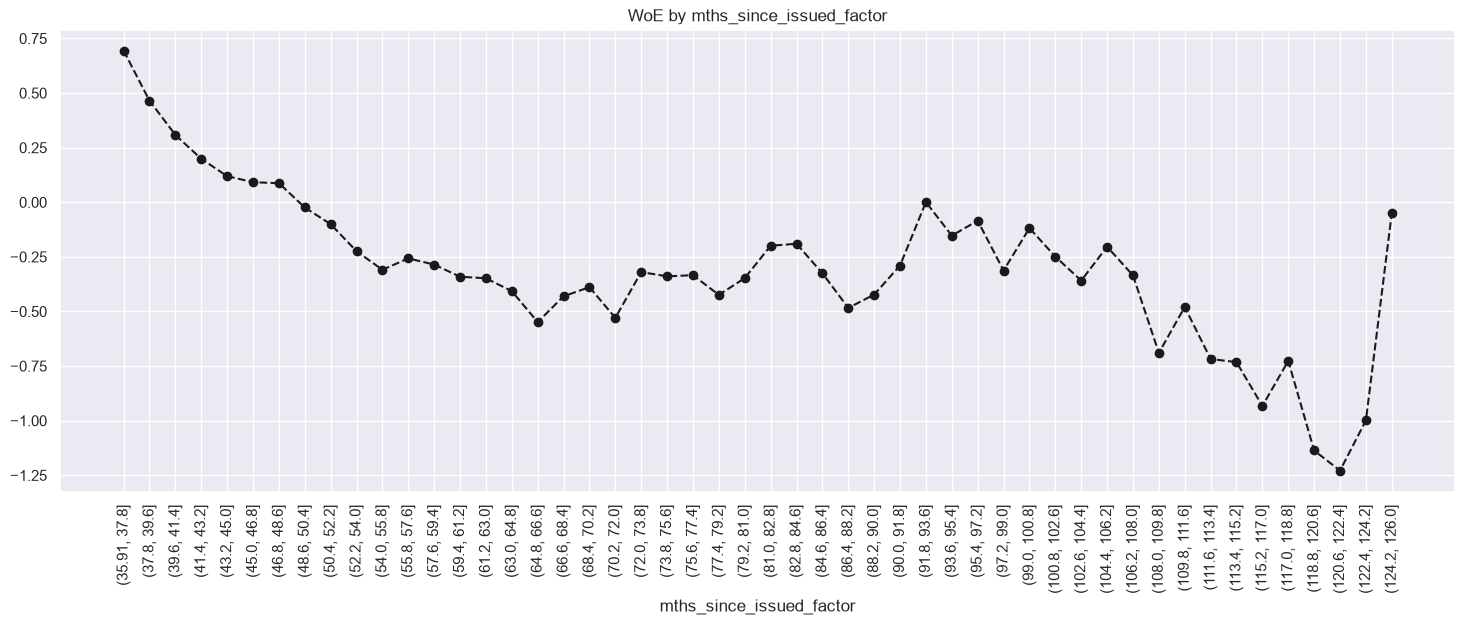

In [47]:
plot_by_woe(df_issued, 90)

In [48]:
# self test on cut into 30
df_input_prep['mths_since_issued_fac_test'] = pd.cut(df_input_prep['mths_since_issued'],30)
df_issued_test = woe_conti(df_input_prep, 'mths_since_issued_fac_test', df_target_prep)
df_issued_test
# slices could be <39, 39-42, 42-48, 48-51 ....
# 30 missed the 38 point, might be too small slices

,mths_since_issued_fac_test,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 39.0]",67806,0.934165,0.181772,63342.0,4464.0,0.190646,0.109471,0.554758,0.110187
1,"(39.0, 42.0]",52395,0.915698,0.140459,47978.0,4417.0,0.144403,0.108318,0.287537,0.110187
2,"(42.0, 45.0]",43624,0.903333,0.116946,39407.0,4217.0,0.118606,0.103414,0.137075,0.110187
3,"(45.0, 48.0]",36616,0.899033,0.098159,32919.0,3697.0,0.099079,0.090662,0.088783,0.110187
4,"(48.0, 51.0]",33344,0.886096,0.089387,29546.0,3798.0,0.088927,0.093138,-0.046271,0.110187
5,"(51.0, 54.0]",28577,0.871540,0.076608,24906.0,3671.0,0.074962,0.090024,-0.183100,0.110187
6,"(54.0, 57.0]",22406,0.860707,0.060065,19285.0,3121.0,0.058044,0.076536,-0.276571,0.110187
7,"(57.0, 60.0]",16398,0.859800,0.043959,14099.0,2299.0,0.042435,0.056378,-0.284115,0.110187
8,"(60.0, 63.0]",14916,0.849826,0.039986,12676.0,2240.0,0.038152,0.054932,-0.364510,0.110187
9,"(63.0, 66.0]",11027,0.832411,0.029561,9179.0,1848.0,0.027627,0.045319,-0.494931,0.110187


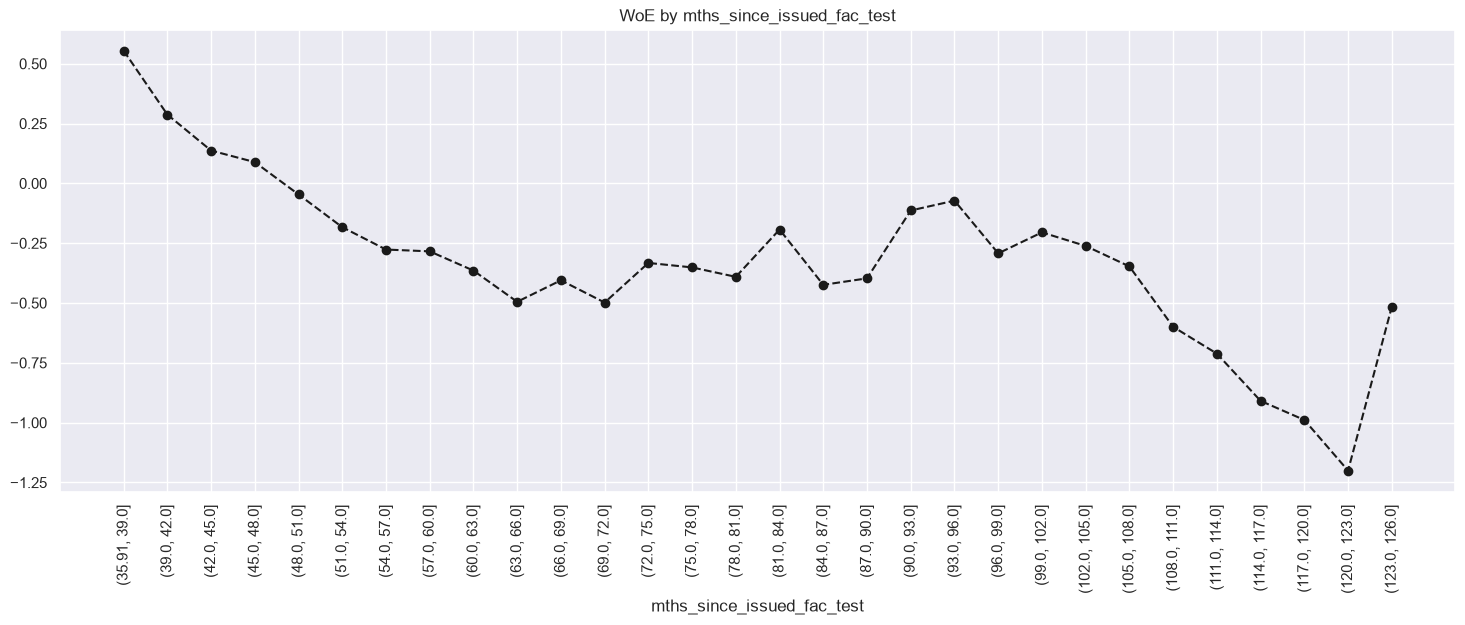

In [49]:
plot_by_woe(df_issued_test, 90)

In [50]:
# self test on cut into 40 
df_input_prep['mths_since_issued_fac_test'] = pd.cut(df_input_prep['mths_since_issued'],40)
df_issued_test = woe_conti(df_input_prep, 'mths_since_issued_fac_test', df_target_prep)
df_issued_test
# similar, might also work

,mths_since_issued_fac_test,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 38.25]",59252,0.935918,0.158841,55455.0,3797.0,0.166907,0.093114,0.583616,0.111459
1,"(38.25, 40.5]",23650,0.920254,0.063400,21764.0,1886.0,0.065505,0.046250,0.348054,0.111459
2,"(40.5, 42.75]",37299,0.914260,0.099990,34101.0,3198.0,0.102637,0.078425,0.269056,0.111459
3,"(42.75, 45.0]",43624,0.903333,0.116946,39407.0,4217.0,0.118606,0.103414,0.137075,0.111459
4,"(45.0, 47.25]",24647,0.899460,0.066073,22169.0,2478.0,0.066724,0.060768,0.093498,0.111459
5,"(47.25, 49.5]",23723,0.894448,0.063596,21219.0,2504.0,0.063865,0.061406,0.039263,0.111459
6,"(49.5, 51.75]",21590,0.883604,0.057878,19077.0,2513.0,0.057418,0.061626,-0.070739,0.111459
7,"(51.75, 54.0]",28577,0.871540,0.076608,24906.0,3671.0,0.074962,0.090024,-0.183100,0.111459
8,"(54.0, 56.25]",15767,0.858312,0.042268,13533.0,2234.0,0.040731,0.054784,-0.296408,0.111459
9,"(56.25, 58.5]",12689,0.862637,0.034016,10946.0,1743.0,0.032945,0.042744,-0.260379,0.111459


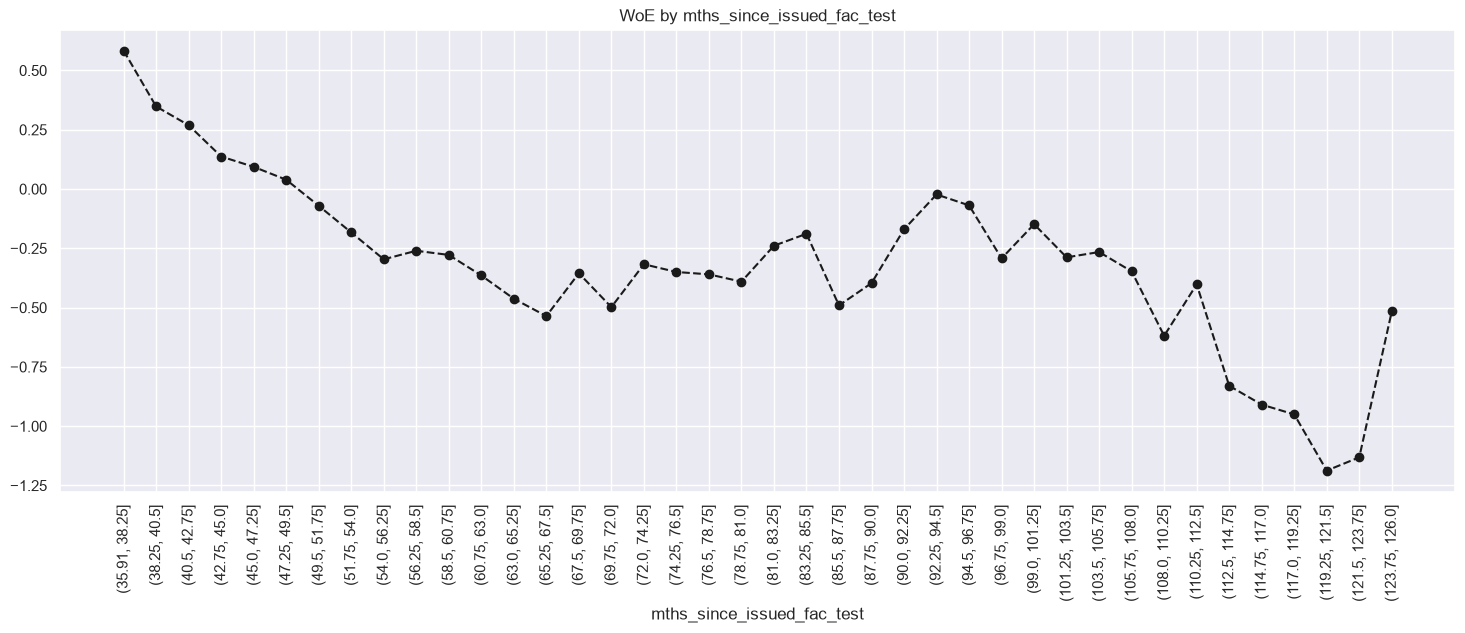

In [51]:
plot_by_woe(df_issued_test, 90)

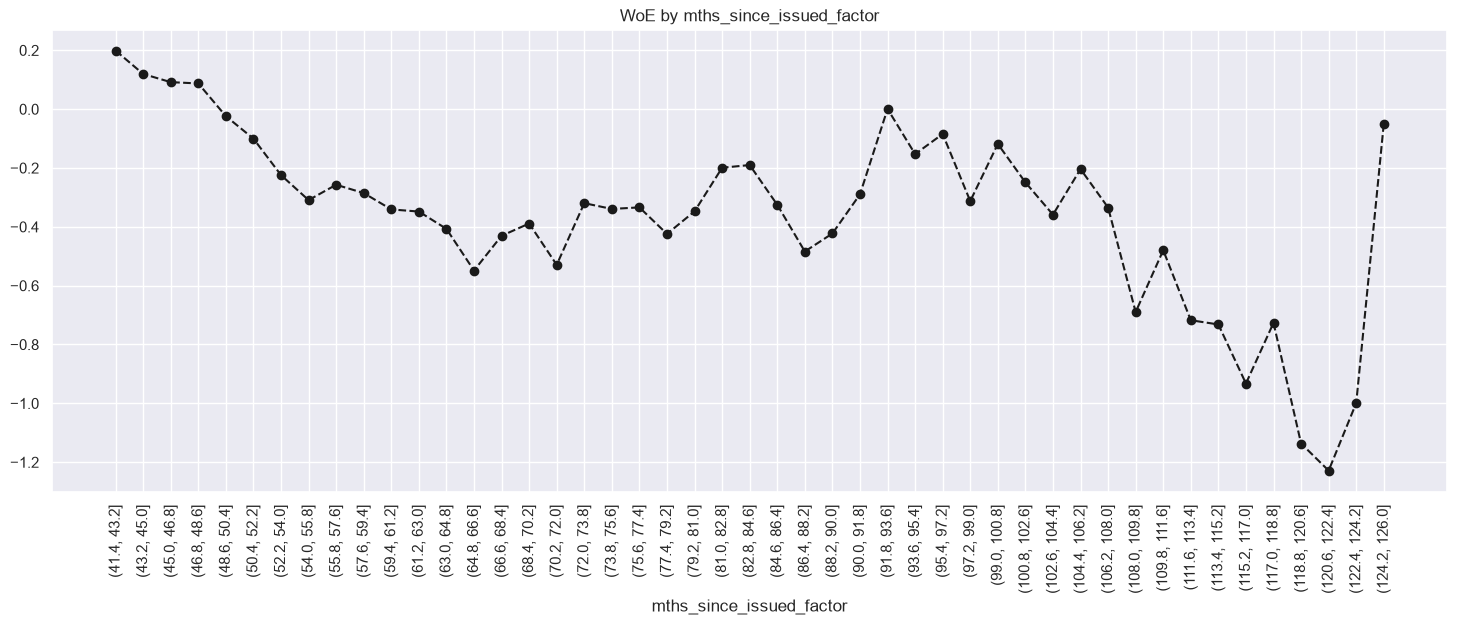

In [52]:
# follow the program first, testing can be used later for my own verification 
plot_by_woe(df_issued.iloc[3: , :],90)

In [53]:
df_input_prep['mths_since_issued_<38'] = np.where(df_input_prep['mths_since_issued'].isin(range(38)),1,0)
df_input_prep['mths_since_issued_38-39'] = np.where(df_input_prep['mths_since_issued'].isin(range(38,40)),1,0)
df_input_prep['mths_since_issued_40-41'] = np.where(df_input_prep['mths_since_issued'].isin(range(40,42)),1,0)
df_input_prep['mths_since_issued_42-48'] = np.where(df_input_prep['mths_since_issued'].isin(range(42,49)),1,0)
df_input_prep['mths_since_issued_49-52'] = np.where(df_input_prep['mths_since_issued'].isin(range(49,53)),1,0)
df_input_prep['mths_since_issued_53-64'] = np.where(df_input_prep['mths_since_issued'].isin(range(53,65)),1,0)
df_input_prep['mths_since_issued_65-84'] = np.where(df_input_prep['mths_since_issued'].isin(range(65,85)),1,0)
df_input_prep['mths_since_issued_>84'] = np.where(df_input_prep['mths_since_issued'].isin(range(85,int(df_input_prep['mths_since_issued'].max()))),1,0)

In [54]:
# 10. interest rate 
df_input_prep['int_factor'] = pd.cut(df_input_prep['int_rate'],50)
df_int = woe_conti(df_input_prep, 'int_factor', df_target_prep)
df_int

,int_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(5.399, 5.833]",785,0.961783,0.002104,755.0,30.0,0.002272,0.000736,1.127775,0.343349
1,"(5.833, 6.246]",8459,0.980376,0.022677,8293.0,166.0,0.024960,0.004071,1.813434,0.343349
2,"(6.246, 6.658]",7826,0.971505,0.020980,7603.0,223.0,0.022883,0.005469,1.431381,0.343349
3,"(6.658, 7.071]",1816,0.973018,0.004868,1767.0,49.0,0.005318,0.001202,1.487473,0.343349
4,"(7.071, 7.484]",3143,0.976456,0.008426,3069.0,74.0,0.009237,0.001815,1.627297,0.343349
5,"(7.484, 7.897]",12581,0.962324,0.033727,12107.0,474.0,0.036439,0.011624,1.142587,0.343349
6,"(7.897, 8.31]",9687,0.949314,0.025969,9196.0,491.0,0.027678,0.012041,0.832335,0.343349
7,"(8.31, 8.722]",6594,0.965271,0.017677,6365.0,229.0,0.019157,0.005616,1.227103,0.343349
8,"(8.722, 9.135]",9539,0.937415,0.025572,8942.0,597.0,0.026913,0.014640,0.608852,0.343349
9,"(9.135, 9.548]",6681,0.963928,0.017910,6440.0,241.0,0.019383,0.005910,1.187742,0.343349


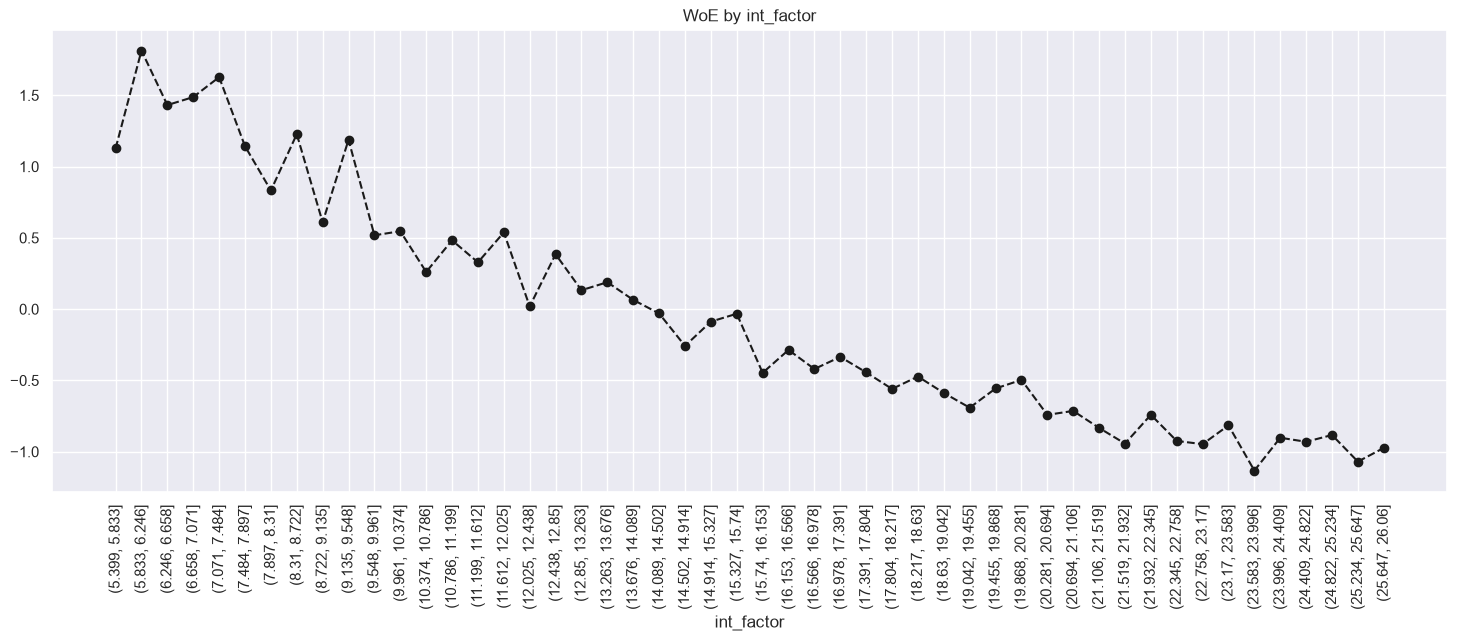

In [55]:
plot_by_woe(df_int, 90)

In [56]:
df_input_prep['int_rate_<9.548'] = np.where((df_input_prep['int_rate']<=9.548),1,0)
df_input_prep['int_rate_9.548-12.025'] = np.where((df_input_prep['int_rate']>9.548)&(df_input_prep['int_rate']<=12.025),1,0)
df_input_prep['int_rate_12.025-15.74'] = np.where((df_input_prep['int_rate']>12.025)&(df_input_prep['int_rate']<=15.74),1,0)
df_input_prep['int_rate_15.74-20.281'] = np.where((df_input_prep['int_rate']>15.74)&(df_input_prep['int_rate']<=20.281),1,0)
df_input_prep['int_rate_>20.281'] = np.where((df_input_prep['int_rate']>20.281),1,0)

In [57]:
# 11. Funded amount
df_input_prep['fund_amt_factor'] = pd.cut(df_input_prep['funded_amnt'],50)
df_fundamt = woe_conti(df_input_prep, 'fund_amt_factor', df_target_prep)
df_fundamt

,fund_amt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(465.5, 1190.0]",1224,0.905229,0.003281,1108.0,116.0,0.003335,0.002845,0.158977,0.014139
1,"(1190.0, 1880.0]",3028,0.903897,0.008117,2737.0,291.0,0.008238,0.007136,0.143549,0.014139
2,"(1880.0, 2570.0]",6018,0.893819,0.016133,5379.0,639.0,0.016190,0.015670,0.032608,0.014139
3,"(2570.0, 3260.0]",7248,0.889073,0.019430,6444.0,804.0,0.019395,0.019717,-0.016440,0.014139
4,"(3260.0, 3950.0]",4751,0.891602,0.012736,4236.0,515.0,0.012749,0.012629,0.009463,0.014139
5,"(3950.0, 4640.0]",9023,0.890945,0.024189,8039.0,984.0,0.024196,0.024131,0.002689,0.014139
6,"(4640.0, 5330.0]",15903,0.892159,0.042632,14188.0,1715.0,0.042703,0.042057,0.015238,0.014139
7,"(5330.0, 6020.0]",17236,0.906069,0.046206,15617.0,1619.0,0.047004,0.039703,0.168806,0.014139
8,"(6020.0, 6710.0]",6914,0.887619,0.018535,6137.0,777.0,0.018471,0.019054,-0.031094,0.014139
9,"(6710.0, 7400.0]",11806,0.898018,0.031649,10602.0,1204.0,0.031910,0.029526,0.077648,0.014139


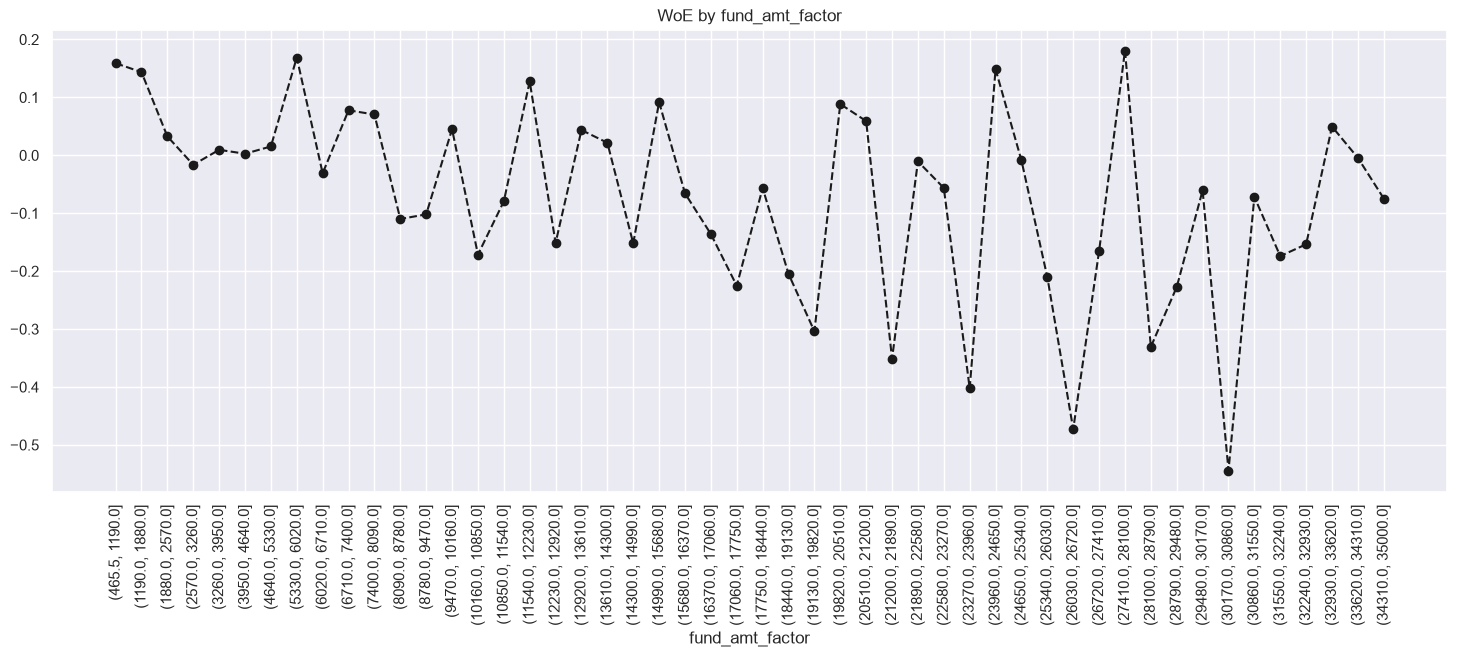

In [58]:
plot_by_woe(df_fundamt, 90)
# due to this great variation, this can not be used for PD model, as it can't be defined as dummies
# no fine classing

In [59]:
# HOMEWORK
# 11. Months since early crline
# check unique number first
df_input_prep['mths_since_earlist_crline'].unique()

array([372., 240., 317., 230., 233., 214., 155., 194., 165., 239., 169.,
       237., 398., 173., 175., 110., 202., 184.,  93., 204., 218., 255.,
       152., 103., 276., 215., 326., 289., 187., 180., 186., 306., 164.,
       304., 192., 235., 244., 181., 114., 312., 190., 212., 157., 229.,
       273., 405., 185., 148., 261., 147., 234., 242.,  99., 243., 158.,
       178., 277., 168., 197., 142., 136., 223., 129., 412., 256., 150.,
       254., 106., 464., 128., 266., 272., 236., 296., 288., 346., 163.,
       156., 587., 251., 222., 300., 122., 268., 205., 219., 335., 231.,
       310., 135., 432., 303., 172., 313., 258., 138., 151., 259., 220.,
       166., 143., 499., 260., 225., 389., 241., 191., 213., 224., 249.,
       488., 332., 161., 141., 353., 357., 413., 322., 227., 302., 195.,
       200., 246., 159., 117., 275., 299., 318., 182., 497., 356., 217.,
       104., 339., 278., 348., 325., 507., 331., 257., 221., 414., 247.,
       267., 102., 291., 384., 179.,  79., 193., 25

In [60]:
# found less than 50 slices, so investigate why? 
bins = pd.cut(df_input_prep['mths_since_earlist_crline'],50)
bins.value_counts().sort_index()
# since there are some bins counts as 0, we could just use the countinous number in the chart

mths_since_earlist_crline
(-0.587, 11.74]        24
(11.74, 23.48]          0
(23.48, 35.22]          0
(35.22, 46.96]          0
(46.96, 58.7]           0
(58.7, 70.44]           0
(70.44, 82.18]        722
(82.18, 93.92]       1929
(93.92, 105.66]      2817
(105.66, 117.4]      5092
(117.4, 129.14]      9217
(129.14, 140.88]    11701
(140.88, 152.62]    13568
(152.62, 164.36]    16266
(164.36, 176.1]     19391
(176.1, 187.84]     20434
(187.84, 199.58]    26096
(199.58, 211.32]    28421
(211.32, 223.06]    27027
(223.06, 234.8]     21901
(234.8, 246.54]     19682
(246.54, 258.28]    18090
(258.28, 270.02]    17958
(270.02, 281.76]    14875
(281.76, 293.5]     14211
(293.5, 305.24]     10240
(305.24, 316.98]     7616
(316.98, 328.72]     8603
(328.72, 340.46]     8307
(340.46, 352.2]      7243
(352.2, 363.94]      5532
(363.94, 375.68]     5446
(375.68, 387.42]     4640
(387.42, 399.16]     4203
(399.16, 410.9]      3494
(410.9, 422.64]      3068
(422.64, 434.38]     2283
(434.38, 446

In [61]:
df_input_prep['mths_crline_factor'] = pd.cut(df_input_prep['mths_since_earlist_crline'],50)
df_crline = woe_conti(df_input_prep, 'mths_crline_factor', df_target_prep)
df_crline

,mths_crline_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.587, 11.74]",24,0.875000,0.000064,21.0,3.0,0.000063,0.000074,-0.151835,0.016273
1,"(70.44, 82.18]",722,0.898892,0.001936,649.0,73.0,0.001953,0.001790,0.087228,0.016273
2,"(82.18, 93.92]",1929,0.884914,0.005171,1707.0,222.0,0.005138,0.005444,-0.057930,0.016273
3,"(93.92, 105.66]",2817,0.857295,0.007552,2415.0,402.0,0.007269,0.009858,-0.304742,0.016273
4,"(105.66, 117.4]",5092,0.871170,0.013650,4436.0,656.0,0.013351,0.016087,-0.186397,0.016273
5,"(117.4, 129.14]",9217,0.864381,0.024709,7967.0,1250.0,0.023979,0.030654,-0.245581,0.016273
6,"(129.14, 140.88]",11701,0.865482,0.031368,10127.0,1574.0,0.030480,0.038599,-0.236160,0.016273
7,"(140.88, 152.62]",13568,0.876106,0.036373,11887.0,1681.0,0.035777,0.041223,-0.141688,0.016273
8,"(152.62, 164.36]",16266,0.879011,0.043605,14298.0,1968.0,0.043034,0.048261,-0.114643,0.016273
9,"(164.36, 176.1]",19391,0.883761,0.051983,17137.0,2254.0,0.051579,0.055275,-0.069212,0.016273


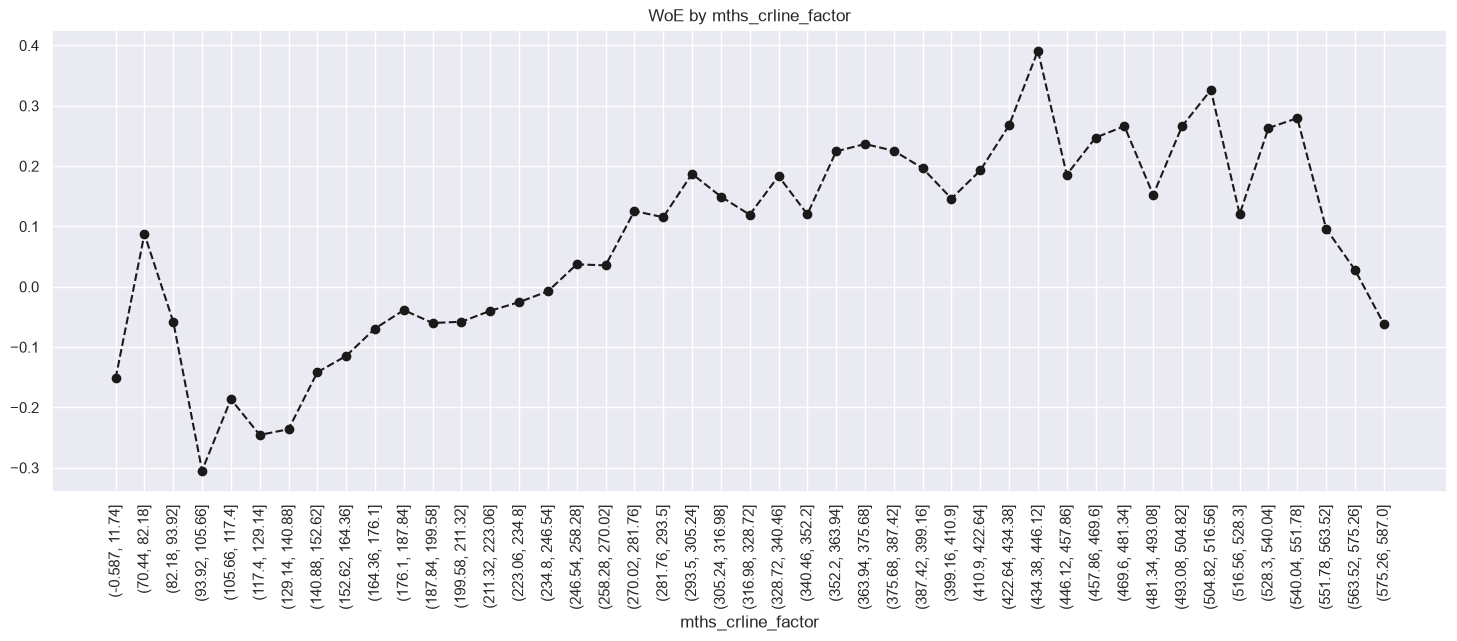

In [62]:
plot_by_woe(df_crline, 90)

In [100]:
# the first 6 fluncuate a lot, but obs number small, group up them; 
# <140.88, 140.88 - 164.36, 164.36-246.54, 246.54-270.02, 270.02-352.2, above with low number of obs and very flunctuate
df_input_prep['mths_since_earlist_crline_<140'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(140)), 1, 0)
df_input_prep['mths_since_earlist_crline_140-164'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(140, 165)), 1, 0)
df_input_prep['mths_since_earlist_crline_165-247'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(165, 248)), 1, 0)
df_input_prep['mths_since_earlist_crline_248-270'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(248, 271)), 1, 0)
df_input_prep['mths_since_earlist_crline_271-352'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(271, 353)), 1, 0)
df_input_prep['mths_since_earlist_crline_>352'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(353, int(df_input_prep['mths_since_earlist_crline'].max()))), 1, 0)

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/3063343281.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_earlist_crline_140-164'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(140, 165)), 1, 0)


In [64]:
# check the number of unique varaiables first to see what approach 
a=df_input_prep['installment'].unique() # ~many
b=df_input_prep['delinq_2yrs'].unique()# 20
c=df_input_prep['open_acc'].unique() #60
d=df_input_prep['pub_rec'].unique() # 20
e=df_input_prep['total_acc'].unique() # ~160
f=df_input_prep['acc_now_delinq'].unique() #5
print(a)
print(b)
print(c)
print(d)
print(e)
print(f)
# thus b, c, d, f, can use the variable directly, where the other two need cuts

[762.08 343.39 648.56 ... 718.44 735.11 464.48]
[ 0.  1.  4.  2.  5.  3.  6.  9.  8.  7. 11. 24. 10. 12. 18. 13. 14. 17.
 19. 15. 16. 22. 21. 29.]
[20. 15.  9. 14.  5. 13. 11.  6. 10.  7. 16.  4.  8. 12. 17.  3. 18. 26.
 24.  2. 19. 25. 27. 30. 23. 22. 21.  1. 29. 33. 28. 34.  0. 41. 38. 32.
 37. 31. 42. 40. 45. 46. 35. 36. 39. 44. 43. 49. 50. 53. 47. 48. 55. 51.
 54. 62. 76. 84. 58. 52. 75.]
[ 0.  1.  3.  2.  5.  4.  6.  7.  9. 10. 13.  8. 19. 11. 17. 34. 16. 12.
 40. 18. 54. 15. 63. 21.]
[ 32.  38.  20.  13.  30.  26.   6.  21.  36.  48.  25.  33.  27.  23.
  44.   9.  10.  18.  31.   5.  19.  15.  39.  12.  57.  24.  22.  17.
  16.  42.   7.  29.  28.  34.  43.  63.  14.  11.  40.  37.  41.  45.
  35.  49.  54.  52.  53.  60.  56.   4.   8.  47.  51.  46.  61.  59.
  50.  58.   0.  64.   3.  55.  62.   2.   1.  71. 105.  66.  68.  69.
  67.  80.  70.  65.  75.  85.  93.  83.  73.  78.  81.  74.  84.  77.
  89.  87.  72.  76. 117.  90.  95.  79.  91. 121. 119. 100. 118.  86.
 102.  8

In [65]:
# 12. Delinque for 2 years
df_delinq2yr = woe_conti(df_input_prep, 'delinq_2yrs', df_target_prep)
df_delinq2yr

,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,306417,0.890499,0.821432,272864.0,33553.0,0.821261,0.822821,-0.001898,inf
1,1.0,44927,0.893249,0.120439,40131.0,4796.0,0.120786,0.117612,0.026622,inf
2,2.0,13118,0.889007,0.035166,11662.0,1456.0,0.035100,0.035706,-0.017102,inf
3,3.0,4550,0.883297,0.012197,4019.0,531.0,0.012096,0.013022,-0.073719,inf
4,4.0,1868,0.898822,0.005008,1679.0,189.0,0.005053,0.004635,0.086462,inf
5,5.0,966,0.881988,0.002590,852.0,114.0,0.002564,0.002796,-0.086357,inf
6,6.0,501,0.902196,0.001343,452.0,49.0,0.001360,0.001202,0.124117,inf
7,7.0,279,0.860215,0.000748,240.0,39.0,0.000722,0.000956,-0.280668,inf
8,8.0,148,0.905405,0.000397,134.0,14.0,0.000403,0.000343,0.161037,inf
9,9.0,89,0.887640,0.000239,79.0,10.0,0.000238,0.000245,-0.030882,inf


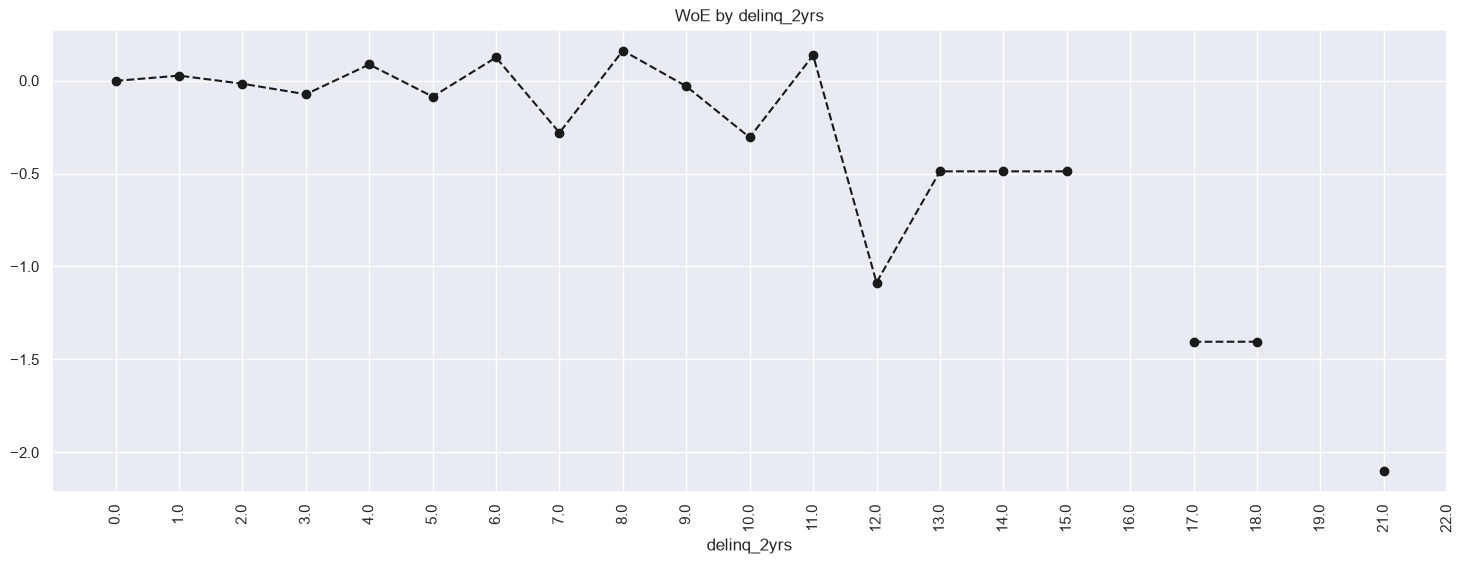

In [66]:
plot_by_woe(df_delinq2yr, 90)

In [67]:
# 0 on its own, 1-3, then >=4
df_input_prep['delinq_2yrs_0'] = np.where((df_input_prep['delinq_2yrs'] == 0), 1, 0)
df_input_prep['delinq_2yrs_1-3'] = np.where((df_input_prep['delinq_2yrs'] >= 1) & (df_input_prep['delinq_2yrs'] <= 3), 1, 0)
df_input_prep['delinq_2yrs_>=4'] = np.where((df_input_prep['delinq_2yrs'] >= 9), 1, 0)

In [68]:
# 13. Open Accout
df_openacc = woe_conti(df_input_prep, 'open_acc', df_target_prep)
df_openacc

/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,29,0.758621,0.000078,22.0,7.0,0.000066,0.000172,-0.952613,inf
1,1.0,110,0.872727,0.000295,96.0,14.0,0.000289,0.000343,-0.172454,inf
2,2.0,1456,0.845467,0.003903,1231.0,225.0,0.003705,0.005518,-0.398263,inf
3,3.0,4378,0.873687,0.011736,3825.0,553.0,0.011512,0.013561,-0.163789,inf
4,4.0,10028,0.891504,0.026883,8940.0,1088.0,0.026907,0.026681,0.008449,inf
...,...,...,...,...,...,...,...,...,...,...
56,58.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
57,62.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
58,75.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
59,76.0,2,0.000000,0.000005,0.0,2.0,0.000000,0.000049,-inf,inf


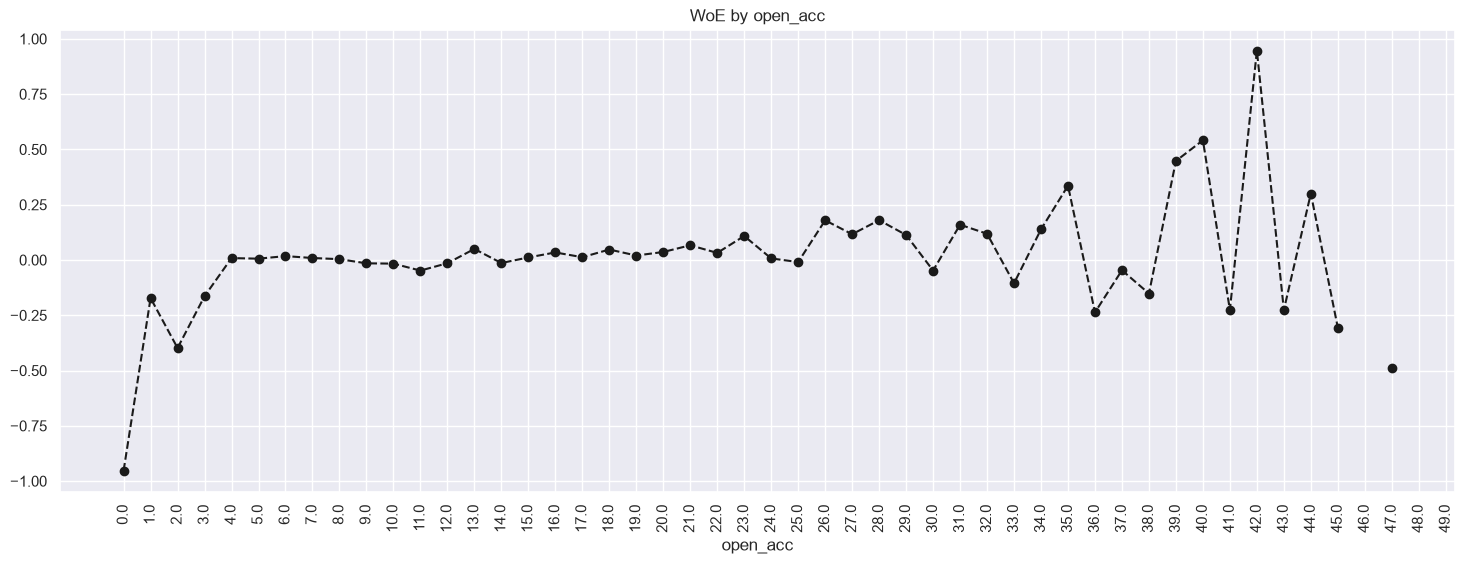

In [69]:
plot_by_woe(df_openacc, 90)

In [70]:
# groups:
df_input_prep['open_acc_0'] = np.where((df_input_prep['open_acc'] == 0), 1, 0)
df_input_prep['open_acc_1-3'] = np.where((df_input_prep['open_acc'] >= 1) &(df_input_prep['open_acc'] <= 3), 1, 0)
df_input_prep['open_acc_4-12'] = np.where((df_input_prep['open_acc'] >= 4) &(df_input_prep['open_acc'] <= 12), 1, 0)
df_input_prep['open_acc_13-17'] = np.where((df_input_prep['open_acc'] >= 13) & (df_input_prep['open_acc'] <= 17), 1, 0)
df_input_prep['open_acc_18-22'] = np.where((df_input_prep['open_acc'] >= 18) & (df_input_prep['open_acc'] <= 22), 1, 0)
df_input_prep['open_acc_23-25'] = np.where((df_input_prep['open_acc'] >= 23) & (df_input_prep['open_acc'] <= 25), 1, 0)
df_input_prep['open_acc_26-30'] = np.where((df_input_prep['open_acc'] >= 26) & (df_input_prep['open_acc'] <= 30), 1, 0)

df_input_prep['open_acc_>=31'] = np.where(
    df_input_prep['open_acc'] >= 31, 1, 0
)

In [71]:
# 14 pub_rec
df_pubrec = woe_conti(df_input_prep, 'pub_rec', df_target_prep)
df_pubrec
# most observations are in 0 and 1, 2 and above rearly has any

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,323999,0.889941,0.868565,288340.0,35659.0,0.867840,0.874467,-0.007606,inf
1,1.0,42381,0.893419,0.113613,37864.0,4517.0,0.113962,0.110771,0.028408,inf
2,2.0,4527,0.903247,0.012136,4089.0,438.0,0.012307,0.010741,0.136092,inf
3,3.0,1280,0.920312,0.003431,1178.0,102.0,0.003546,0.002501,0.348856,inf
4,4.0,408,0.924020,0.001094,377.0,31.0,0.001135,0.000760,0.400513,inf
5,5.0,203,0.911330,0.000544,185.0,18.0,0.000557,0.000441,0.232239,inf
6,6.0,117,0.931624,0.000314,109.0,8.0,0.000328,0.000196,0.514161,inf
7,7.0,48,0.958333,0.000129,46.0,2.0,0.000138,0.000049,1.037749,inf
8,8.0,24,1.000000,0.000064,24.0,0.0,0.000072,0.000000,inf,inf
9,9.0,14,0.785714,0.000038,11.0,3.0,0.000033,0.000074,-0.798462,inf


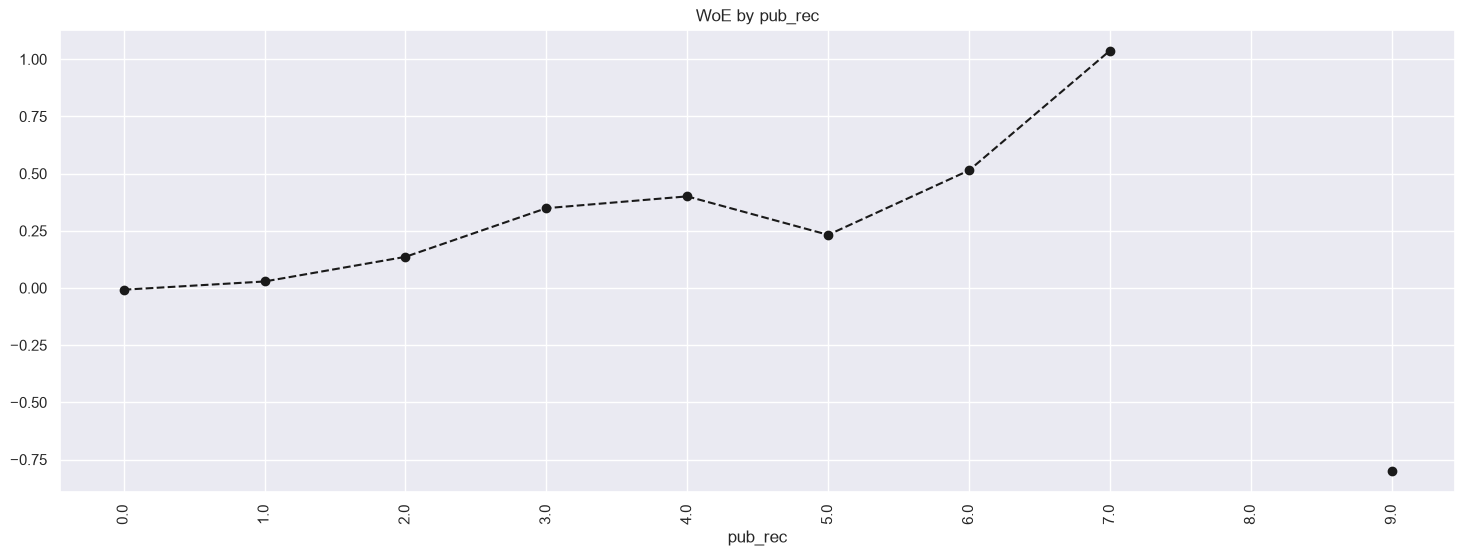

In [72]:
plot_by_woe(df_pubrec, 90)

In [73]:
df_input_prep['pub_rec_=0'] = np.where((df_input_prep['pub_rec']==0),1,0)
df_input_prep['pub_rec_1-2'] = np.where((df_input_prep['pub_rec'] >= 1) & (df_input_prep['pub_rec'] <= 2), 1, 0)
df_input_prep['pub_rec_3-4'] = np.where((df_input_prep['pub_rec'] >= 3) & (df_input_prep['pub_rec'] <= 4), 1, 0)
df_input_prep['pub_rec_>=5'] = np.where((df_input_prep['pub_rec'] >= 5), 1, 0)

In [74]:
# 15 acc_now_delinq
df_accnow_delinq = woe_conti(df_input_prep, 'acc_now_delinq', df_target_prep)
df_accnow_delinq
# same as above, not using this for PD model 

,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,371682,0.890648,0.996392,331038.0,40644.0,0.996352,0.996714,-0.000363,inf
1,1.0,1263,0.899446,0.003386,1136.0,127.0,0.003419,0.003114,0.093337,inf
2,2.0,70,0.928571,0.000188,65.0,5.0,0.000196,0.000123,0.467204,inf
3,3.0,7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.305986,inf
4,4.0,4,1.000000,0.000011,4.0,0.0,0.000012,0.000000,inf,inf
5,5.0,2,0.500000,0.000005,1.0,1.0,0.000003,0.000025,-2.097745,inf


In [75]:
#  installment no need
#a=df_input_prep['installment'].unique() # ~many 
df_input_prep['install_factor'] = pd.cut(df_input_prep['installment'],50)
df_install = woe_conti(df_input_prep, 'install_factor', df_target_prep)
df_install

,install_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(14.276, 43.556]",1812,0.906181,0.004858,1642.0,170.0,0.004942,0.004169,0.170127,0.013497
1,"(43.556, 71.443]",4841,0.897542,0.012978,4345.0,496.0,0.013078,0.012163,0.072460,0.013497
2,"(71.443, 99.329]",6824,0.893025,0.018294,6094.0,730.0,0.018342,0.017902,0.024270,0.013497
3,"(99.329, 127.216]",9138,0.890348,0.024497,8136.0,1002.0,0.024488,0.024572,-0.003444,0.013497
4,"(127.216, 155.102]",10040,0.896514,0.026915,9001.0,1039.0,0.027091,0.025479,0.061332,0.013497
5,"(155.102, 182.988]",16816,0.894208,0.045080,15037.0,1779.0,0.045258,0.043626,0.036717,0.013497
6,"(182.988, 210.875]",17216,0.904798,0.046152,15577.0,1639.0,0.046883,0.040193,0.153964,0.013497
7,"(210.875, 238.761]",15090,0.900398,0.040453,13587.0,1503.0,0.040894,0.036858,0.103905,0.013497
8,"(238.761, 266.648]",18842,0.901391,0.050511,16984.0,1858.0,0.051118,0.045564,0.115026,0.013497
9,"(266.648, 294.534]",20100,0.891095,0.053883,17911.0,2189.0,0.053908,0.053681,0.004225,0.013497


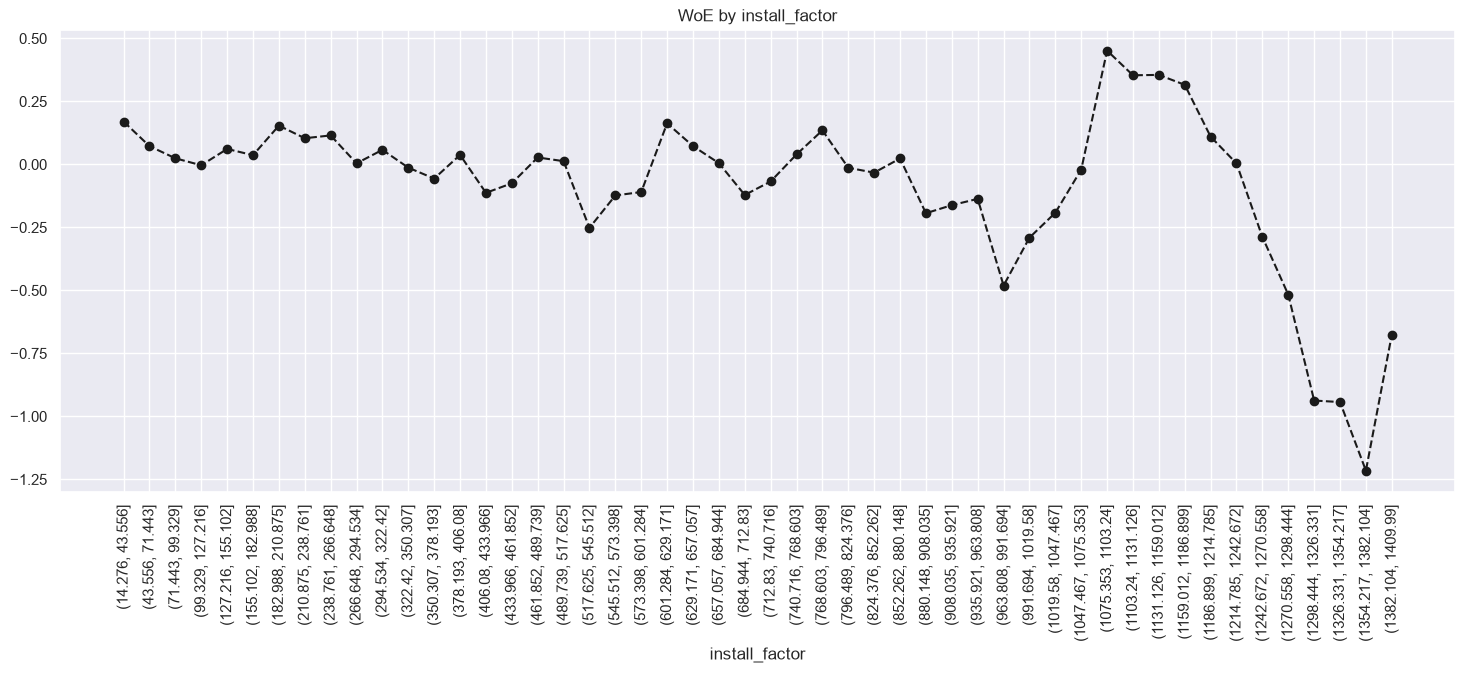

In [76]:
plot_by_woe(df_install, 90)

In [77]:
# 16 rev high limit 
df_input_prep['total_rev_hi_lim_factor'] = pd.cut(df_input_prep['total_rev_hi_lim'], 800)
df_revhi = woe_conti(df_input_prep, 'total_rev_hi_lim_factor', df_target_prep)
df_revhi

/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-9999.999, 12499.999]",104746,0.875107,0.280799,91664.0,13082.0,0.275889,0.320810,-0.150852,inf
1,"(12499.999, 24999.998]",119933,0.881567,0.321512,105729.0,14204.0,0.318221,0.348325,-0.090389,inf
2,"(24999.998, 37499.996]",67522,0.892598,0.181011,60270.0,7252.0,0.181400,0.177841,0.019812,inf
3,"(37499.996, 49999.995]",35158,0.912822,0.094250,32093.0,3065.0,0.096593,0.075163,0.250845,inf
4,"(49999.995, 62499.994]",18441,0.923106,0.049436,17023.0,1418.0,0.051236,0.034774,0.387573,inf
...,...,...,...,...,...,...,...,...,...,...
63,"(1124999.888, 1137499.886]",1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
64,"(1312499.869, 1324999.868]",1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
65,"(1499999.85, 1512499.849]",1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,inf
66,"(1987499.801, 1999999.8]",1,0.000000,0.000003,0.0,1.0,0.000000,0.000025,-inf,inf


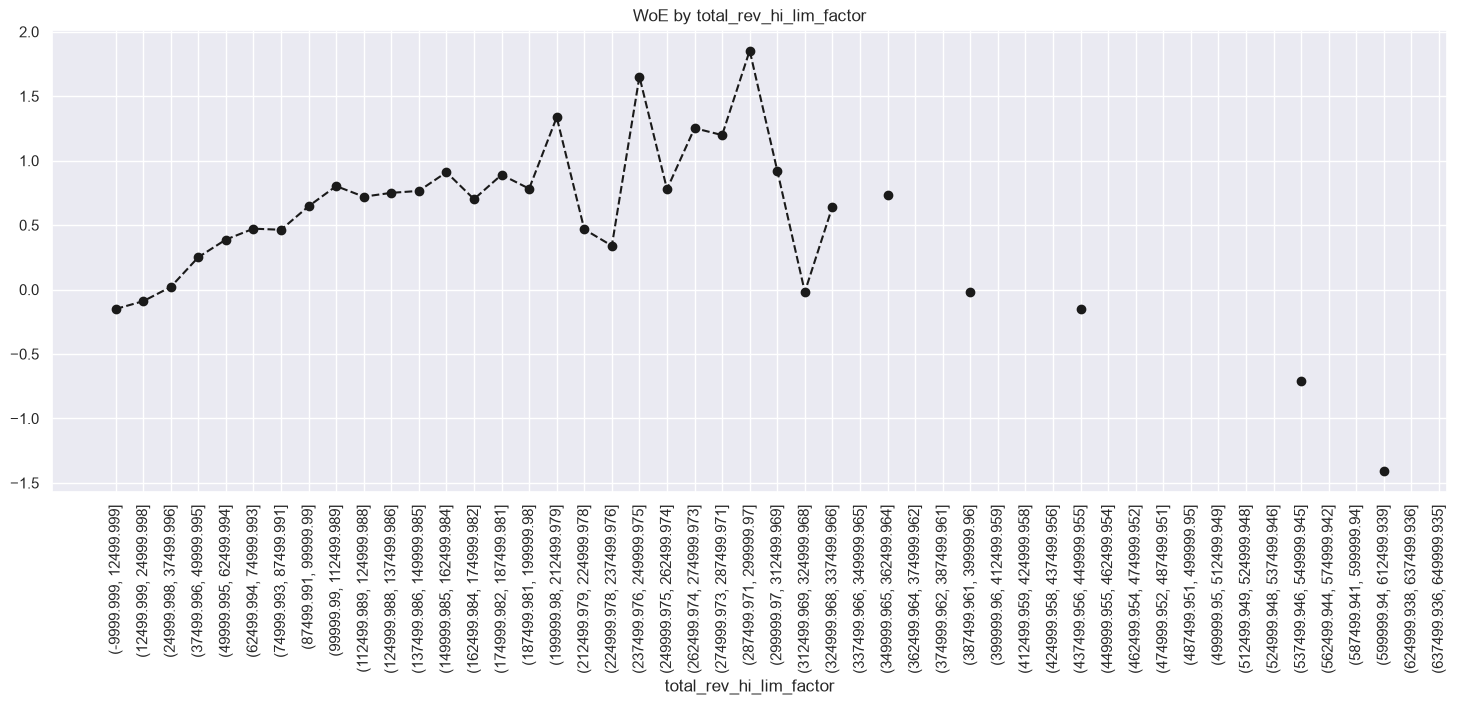

In [78]:
plot_by_woe(df_revhi, 90)

In [79]:
df_input_prep['total_revhi_lim_<=5K'] = np.where((df_input_prep['total_rev_hi_lim'] <= 5000), 1, 0)
df_input_prep['total_revhi_lim_5K-10K'] = np.where((df_input_prep['total_rev_hi_lim'] > 5000) & (df_input_prep['total_rev_hi_lim'] <= 10000), 1, 0)
df_input_prep['total_revhi_lim_10K-20K'] = np.where((df_input_prep['total_rev_hi_lim'] > 10000) & (df_input_prep['total_rev_hi_lim'] <= 20000), 1, 0)
df_input_prep['total_revhi_lim_20K-30K'] = np.where((df_input_prep['total_rev_hi_lim'] > 20000) & (df_input_prep['total_rev_hi_lim'] <= 30000), 1, 0)
df_input_prep['total_revhi_lim_30K-40K'] = np.where((df_input_prep['total_rev_hi_lim'] > 30000) & (df_input_prep['total_rev_hi_lim'] <= 40000), 1, 0)
df_input_prep['total_revhi_lim_40K-55K'] = np.where((df_input_prep['total_rev_hi_lim'] > 40000) & (df_input_prep['total_rev_hi_lim'] <= 55000), 1, 0)
df_input_prep['total_revhi_lim_55K-95K'] = np.where((df_input_prep['total_rev_hi_lim'] > 55000) & (df_input_prep['total_rev_hi_lim'] <= 95000), 1, 0)
df_input_prep['total_revhi_lim_>95K'] = np.where((df_input_prep['total_rev_hi_lim'] > 95000), 1, 0)

In [80]:
# 17. total acc
# e =df_input_prep['total_acc'].unique() # ~160
df_input_prep['total_acc_factor'] = pd.cut(df_input_prep['total_acc'],50)
df_total_acc = woe_conti(df_input_prep, 'total_acc_factor', df_target_prep)
df_total_acc
#some intervals have 0 obs

,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.15, 3.0]",459,0.810458,0.001230,372.0,87.0,0.001120,0.002134,-0.644759,inf
1,"(3.0, 6.0]",6004,0.864757,0.016095,5192.0,812.0,0.015627,0.019913,-0.242371,inf
2,"(6.0, 9.0]",15047,0.873131,0.040337,13138.0,1909.0,0.039543,0.046814,-0.168816,inf
3,"(9.0, 12.0]",25169,0.881283,0.067472,22181.0,2988.0,0.066760,0.073275,-0.093113,inf
4,"(12.0, 15.0]",33651,0.881281,0.090210,29656.0,3995.0,0.089258,0.097969,-0.093124,inf
5,"(15.0, 18.0]",38711,0.887267,0.103775,34347.0,4364.0,0.103377,0.107018,-0.034619,inf
6,"(18.0, 21.0]",40599,0.886155,0.108836,35977.0,4622.0,0.108283,0.113345,-0.045693,inf
7,"(21.0, 24.0]",40163,0.891492,0.107668,35805.0,4358.0,0.107765,0.106871,0.008329,inf
8,"(24.0, 27.0]",36286,0.895442,0.097274,32492.0,3794.0,0.097794,0.093040,0.049828,inf
9,"(27.0, 30.0]",31775,0.899103,0.085181,28569.0,3206.0,0.085986,0.078621,0.089553,inf


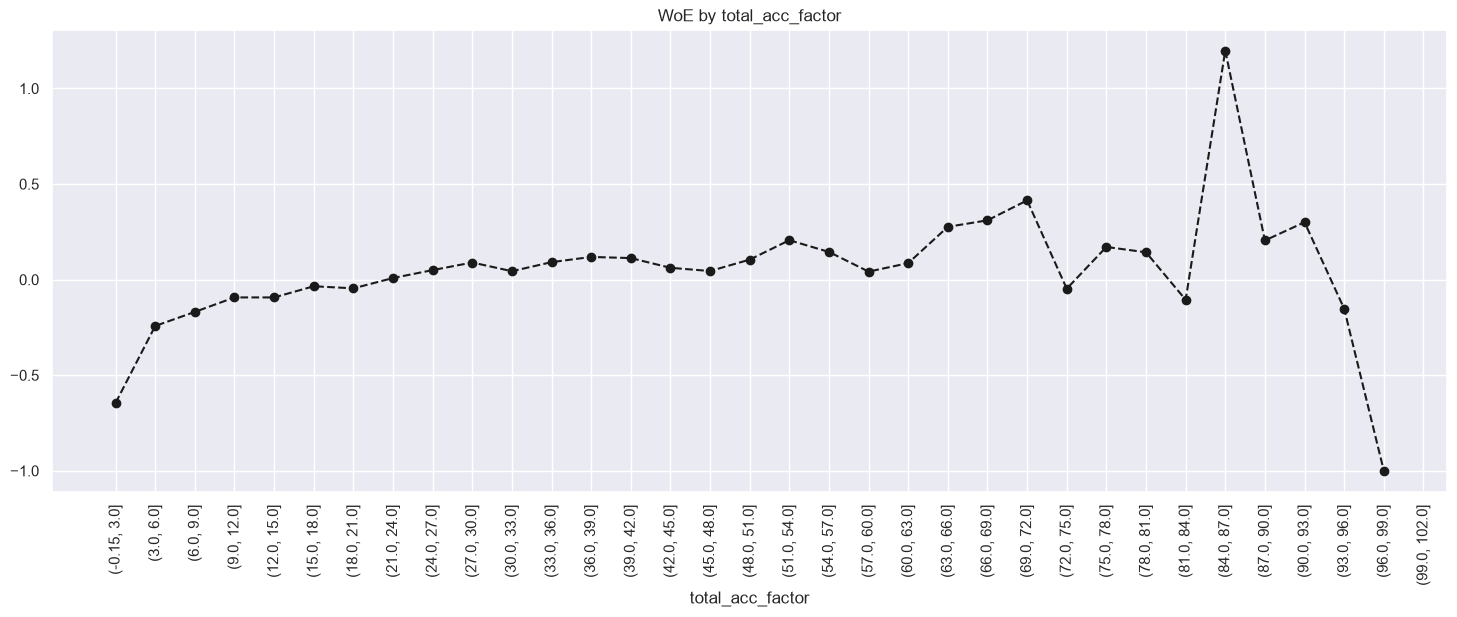

In [81]:
plot_by_woe(df_total_acc, 90)

In [82]:
# Different than the program assigned
df_input_prep['total_acc_<=27'] = np.where((df_input_prep['total_acc']<=27),1,0)
df_input_prep['total_acc_27-48'] = np.where((df_input_prep['total_acc']> 27)&(df_input_prep['total_acc']<=48),1,0)
df_input_prep['total_acc_48-60'] = np.where((df_input_prep['total_acc']> 48)&(df_input_prep['total_acc']<=60),1,0)
df_input_prep['total_acc_>60'] = np.where((df_input_prep['total_acc']> 60),1,0)

In [83]:
# course
# 18. annual income
df_input_prep['annual_inc_factor'] = pd.cut(df_input_prep['annual_inc'],100)
df_annual = woe_conti(df_input_prep, 'annual_inc_factor', df_target_prep)
df_annual

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-5243.882, 73294.82]",231445,0.875901,0.620449,202723.0,28722.0,0.610152,0.704350,-0.143568,inf
1,"(73294.82, 144693.64]",120459,0.912900,0.322922,109967.0,10492.0,0.330977,0.257296,0.251822,inf
2,"(144693.64, 216092.46]",15885,0.925087,0.042584,14695.0,1190.0,0.044229,0.029182,0.415809,inf
3,"(216092.46, 287491.28]",3119,0.927220,0.008361,2892.0,227.0,0.008704,0.005567,0.447009,inf
4,"(287491.28, 358890.1]",1117,0.929275,0.002994,1038.0,79.0,0.003124,0.001937,0.477858,inf
5,"(358890.1, 430288.92]",408,0.933824,0.001094,381.0,27.0,0.001147,0.000662,0.549218,inf
6,"(430288.92, 501687.74]",245,0.946939,0.000657,232.0,13.0,0.000698,0.000319,0.784043,inf
7,"(501687.74, 573086.56]",87,0.919540,0.000233,80.0,7.0,0.000241,0.000172,0.338372,inf
8,"(573086.56, 644485.38]",61,0.868852,0.000164,53.0,8.0,0.000160,0.000196,-0.206895,inf
9,"(644485.38, 715884.2]",51,0.901961,0.000137,46.0,5.0,0.000138,0.000123,0.121459,inf


In [84]:
df_input_prep_temp = df_input_prep.loc[df_input_prep['annual_inc']<=140000,:]
df_input_prep_temp['annual_inc_factor'] = pd.cut(df_input_prep_temp['annual_inc'],50)
df_annual_temp = woe_conti(df_input_prep_temp, 'annual_inc_factor', df_target_prep[df_input_prep_temp.index])
df_annual_temp

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(1757.896, 4658.08]",15,0.800000,0.000043,12.0,3.0,0.000038,0.000077,-0.689458,0.049818
1,"(4658.08, 7420.16]",40,0.750000,0.000114,30.0,10.0,0.000096,0.000256,-0.977140,0.049818
2,"(7420.16, 10182.24]",287,0.874564,0.000818,251.0,36.0,0.000805,0.000920,-0.133818,0.049818
3,"(10182.24, 12944.32]",547,0.828154,0.001558,453.0,94.0,0.001452,0.002402,-0.503155,0.049818
4,"(12944.32, 15706.4]",1210,0.830579,0.003447,1005.0,205.0,0.003222,0.005238,-0.486019,0.049818
5,"(15706.4, 18468.48]",1522,0.847569,0.004335,1290.0,232.0,0.004136,0.005928,-0.360092,0.049818
6,"(18468.48, 21230.56]",2928,0.855533,0.008340,2505.0,423.0,0.008031,0.010809,-0.297080,0.049818
7,"(21230.56, 23992.64]",2495,0.844489,0.007107,2107.0,388.0,0.006755,0.009914,-0.383737,0.049818
8,"(23992.64, 26754.72]",7016,0.848632,0.019985,5954.0,1062.0,0.019088,0.027137,-0.351843,0.049818
9,"(26754.72, 29516.8]",5643,0.857345,0.016074,4838.0,805.0,0.015510,0.020570,-0.282338,0.049818


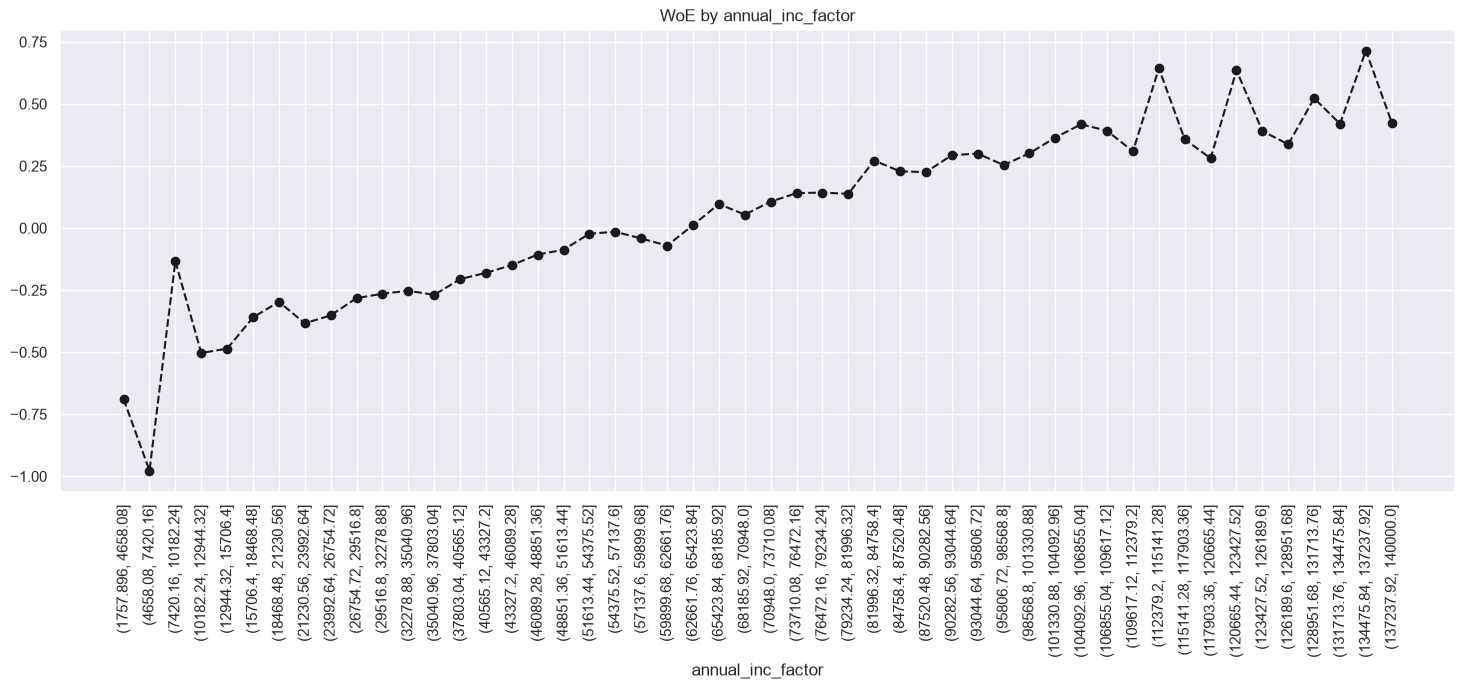

In [85]:
plot_by_woe(df_annual_temp, 90)

In [86]:
df_input_prep['annual_inc_<=20']=np.where((df_input_prep['annual_inc']<=20000),1,0)
df_input_prep['annual_inc_20-30']=np.where((df_input_prep['annual_inc']>20000)&(df_input_prep['annual_inc']<=30000),1,0)
df_input_prep['annual_inc_30-40']=np.where((df_input_prep['annual_inc']>30000)&(df_input_prep['annual_inc']<=40000),1,0)
df_input_prep['annual_inc_40-50']=np.where((df_input_prep['annual_inc']>40000)&(df_input_prep['annual_inc']<=50000),1,0)
df_input_prep['annual_inc_50-60']=np.where((df_input_prep['annual_inc']>50000)&(df_input_prep['annual_inc']<=60000),1,0)
df_input_prep['annual_inc_60-70']=np.where((df_input_prep['annual_inc']>60000)&(df_input_prep['annual_inc']<=70000),1,0)
df_input_prep['annual_inc_70-80']=np.where((df_input_prep['annual_inc']>70000)&(df_input_prep['annual_inc']<=80000),1,0)
df_input_prep['annual_inc_80-90']=np.where((df_input_prep['annual_inc']>80000)&(df_input_prep['annual_inc']<=90000),1,0)
df_input_prep['annual_inc_90-100']=np.where((df_input_prep['annual_inc']>90000)&(df_input_prep['annual_inc']<=100000),1,0)
df_input_prep['annual_inc_100-120']=np.where((df_input_prep['annual_inc']>100000)&(df_input_prep['annual_inc']<=120000),1,0)
df_input_prep['annual_inc_120-140']=np.where((df_input_prep['annual_inc']>120000)&(df_input_prep['annual_inc']<=140000),1,0)
df_input_prep['annual_inc_>140']=np.where((df_input_prep['annual_inc']>140000),1,0)

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/3649580479.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['annual_inc_<=20']=np.where((df_input_prep['annual_inc']<=20000),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/3649580479.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['annual_inc_20-30']=np.where((df_input_prep['annual_inc']>20000)&(df_input_prep['annual_inc']<=30000),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/36495804

In [87]:
# deal with the missing dummies
# 19. mths_since_last_delinq
# 1 as missing, and 0 for not missing
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['mths_since_last_delinq'])]
df_input_prep_temp['mths_since_last_delinq_factor'] = pd.cut(df_input_prep_temp['mths_since_last_delinq'],50)
df_mth_delinq_temp = woe_conti(df_input_prep_temp, 'mths_since_last_delinq_factor', df_target_prep[df_input_prep_temp.index])
df_mth_delinq_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/1455060115.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['mths_since_last_delinq_factor'] = pd.cut(df_input_prep_temp['mths_since_last_delinq'],50)


,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.188, 3.76]",5277,0.871518,0.030531,4599.0,678.0,0.029814,0.036481,-0.201825,inf
1,"(3.76, 7.52]",11167,0.887615,0.064608,9912.0,1255.0,0.064256,0.067528,-0.049661,inf
2,"(7.52, 11.28]",13306,0.892830,0.076983,11880.0,1426.0,0.077014,0.076729,0.003711,inf
3,"(11.28, 15.04]",13216,0.888847,0.076462,11747.0,1469.0,0.076152,0.079042,-0.037256,inf
4,"(15.04, 18.8]",9337,0.894934,0.054020,8356.0,981.0,0.054169,0.052785,0.025891,inf
5,"(18.8, 22.56]",11641,0.892707,0.067350,10392.0,1249.0,0.067368,0.067205,0.002421,inf
6,"(22.56, 26.32]",10887,0.896298,0.062988,9758.0,1129.0,0.063258,0.060748,0.040483,inf
7,"(26.32, 30.08]",10560,0.895076,0.061096,9452.0,1108.0,0.061274,0.059618,0.027398,inf
8,"(30.08, 33.84]",7576,0.902191,0.043832,6835.0,741.0,0.044309,0.039871,0.105539,inf
9,"(33.84, 37.6]",9795,0.897397,0.056670,8790.0,1005.0,0.056982,0.054076,0.052355,inf


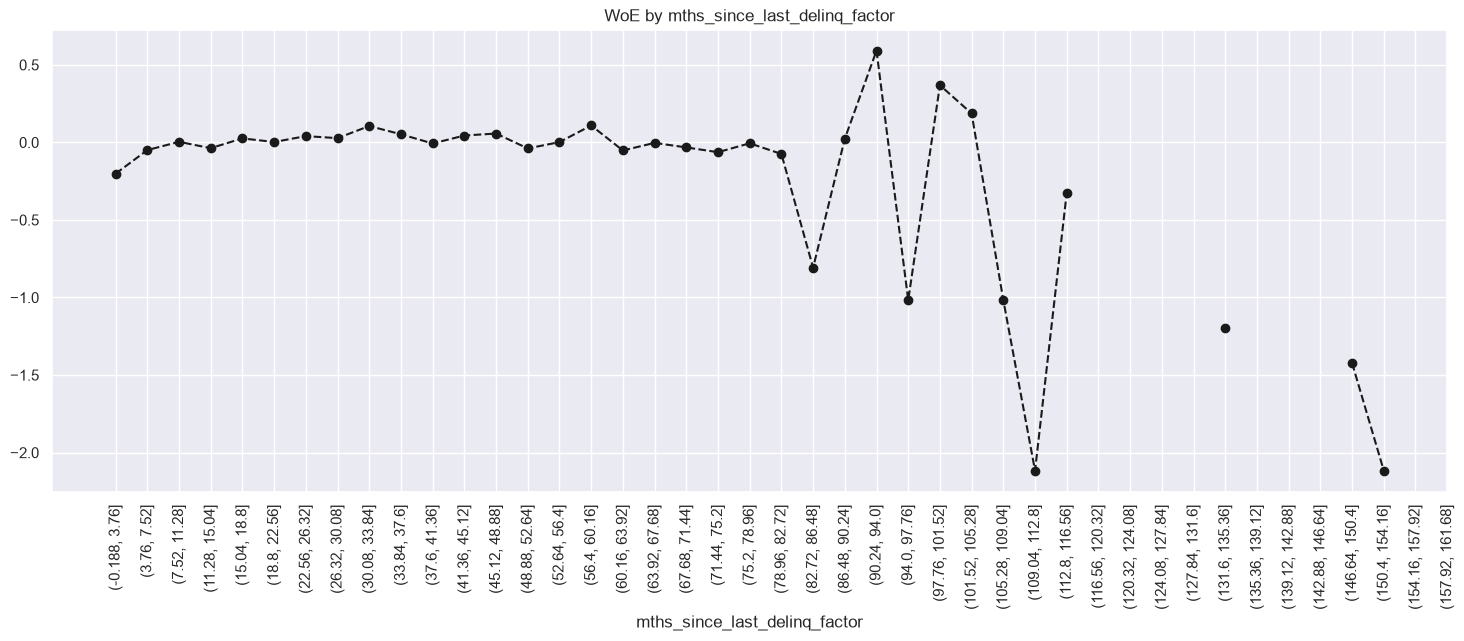

In [88]:
plot_by_woe(df_mth_delinq_temp, 90)

In [89]:
df_input_prep['mths_since_last_delinq_missing'] = np.where((df_input_prep['mths_since_last_delinq'].isnull()),1,0)
df_input_prep['mths_since_last_delinq_0-3'] = np.where((df_input_prep['mths_since_last_delinq']>=0)&(df_input_prep['mths_since_last_delinq']<=3),1,0)
df_input_prep['mths_since_last_delinq_4-30'] = np.where((df_input_prep['mths_since_last_delinq']>=3)&(df_input_prep['mths_since_last_delinq']<=30),1,0)
df_input_prep['mths_since_last_delinq_31-56'] = np.where((df_input_prep['mths_since_last_delinq']>=31)&(df_input_prep['mths_since_last_delinq']<=56),1,0)
df_input_prep['mths_since_last_delinq_>=57'] = np.where((df_input_prep['mths_since_last_delinq']>=57),1,0)


/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2212133452.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_last_delinq_missing'] = np.where((df_input_prep['mths_since_last_delinq'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2212133452.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_last_delinq_0-3'] = np.where((df_input_prep['mths_since_last_delinq']>=0)&(df_input_prep['mths_since_last_delinq']<=3),1,0)
/var/folders/

In [90]:
df_input_prep['dti'].isna().count()

np.int64(373028)

In [91]:
#homework
# 20. dti(debt to income ratio)
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['dti'])]
df_input_prep_temp['dti_factor'] = pd.cut(df_input_prep_temp['dti'],50)
df_dti_temp = woe_conti(df_input_prep_temp, 'dti_factor', df_target_prep[df_input_prep_temp.index])
df_dti_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/3058875730.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['dti_factor'] = pd.cut(df_input_prep_temp['dti'],50)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.04, 0.8]",1553,0.898905,0.004163,1396.0,157.0,0.004202,0.003850,0.087376,0.026725
1,"(0.8, 1.6]",1965,0.896692,0.005268,1762.0,203.0,0.005303,0.004978,0.063254,0.026725
2,"(1.6, 2.399]",2509,0.910323,0.006726,2284.0,225.0,0.006874,0.005518,0.219838,0.026725
3,"(2.399, 3.199]",3234,0.910019,0.008670,2943.0,291.0,0.008858,0.007136,0.216117,0.026725
4,"(3.199, 3.999]",4124,0.907856,0.011055,3744.0,380.0,0.011269,0.009319,0.189994,0.026725
5,"(3.999, 4.799]",5037,0.917213,0.013503,4620.0,417.0,0.013905,0.010226,0.307319,0.026725
6,"(4.799, 5.599]",5989,0.911671,0.016055,5460.0,529.0,0.016433,0.012973,0.236471,0.026725
7,"(5.599, 6.398]",6781,0.914909,0.018178,6204.0,577.0,0.018673,0.014150,0.277362,0.026725
8,"(6.398, 7.198]",7665,0.913372,0.020548,7001.0,664.0,0.021071,0.016283,0.257781,0.026725
9,"(7.198, 7.998]",8747,0.915514,0.023449,8008.0,739.0,0.024102,0.018123,0.285153,0.026725


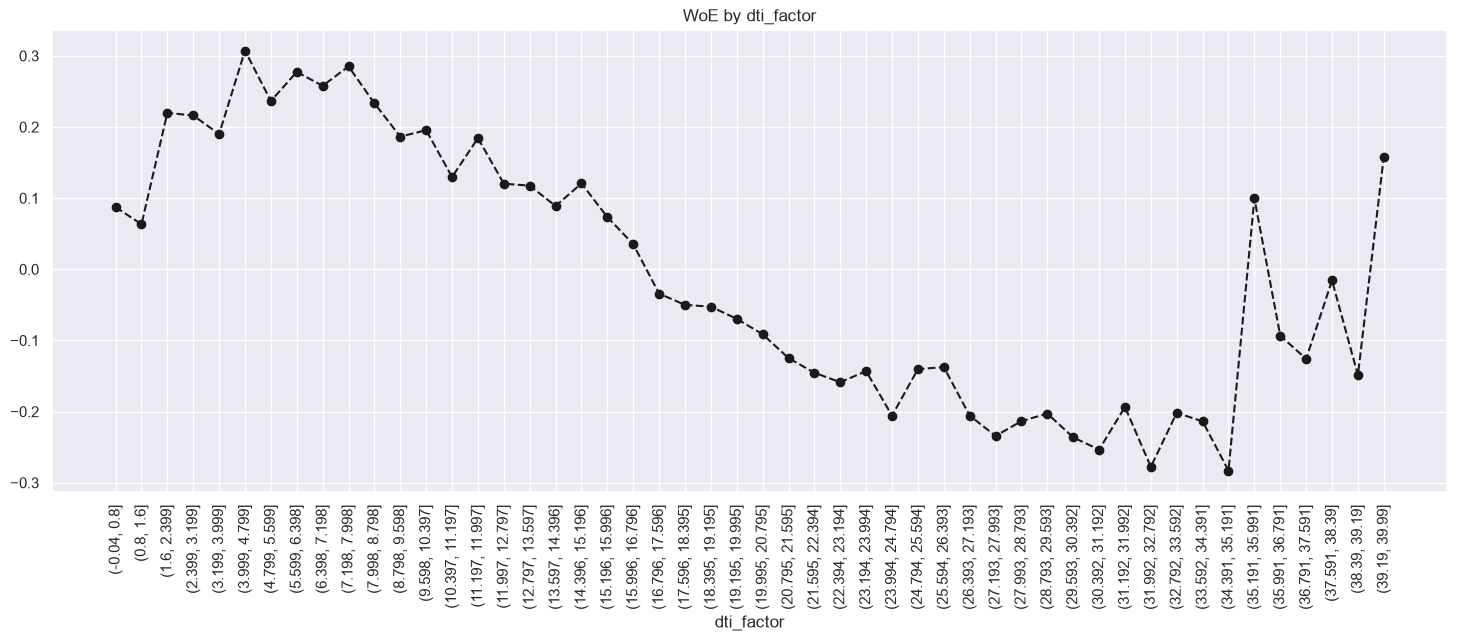

In [92]:
plot_by_woe(df_dti_temp, 90)

In [93]:
# <=1.6, 1.6-8.8, 8.8-15.2, 15.2-16, 16-20.8,20.8-27.2, >=27.2
df_input_prep['dti_missing'] = np.where((df_input_prep['dti'].isnull()),1,0)
df_input_prep['dti_<=1.6']= np.where((df_input_prep['dti'] <=1.6),1,0)
df_input_prep['dti_1.6-4']= np.where((df_input_prep['dti'] > 1.6) & (df_input_prep['dti'] <= 4), 1, 0)
df_input_prep['dti_4-8.8']= np.where((df_input_prep['dti'] > 4) & (df_input_prep['dti'] <= 8.8), 1, 0)
df_input_prep['dti_8.8-12']= np.where((df_input_prep['dti'] > 8.8) & (df_input_prep['dti'] <= 12), 1, 0)
df_input_prep['dti_12-16']= np.where((df_input_prep['dti'] > 12) & (df_input_prep['dti'] <= 16), 1, 0)
df_input_prep['dti_16-20.8']= np.where((df_input_prep['dti'] > 16) & (df_input_prep['dti'] <= 20.8), 1, 0)
df_input_prep['dti_20.8-24']= np.where((df_input_prep['dti'] > 20.8) & (df_input_prep['dti'] <= 24), 1, 0)
df_input_prep['dti_24-35']= np.where((df_input_prep['dti'] > 24) & (df_input_prep['dti'] <= 35), 1, 0)
df_input_prep['dti_>35']= np.where(df_input_prep['dti'] > 35, 1, 0)

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2083085678.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['dti_missing'] = np.where((df_input_prep['dti'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2083085678.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['dti_<=1.6']= np.where((df_input_prep['dti'] <=1.6),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2083085678.py:4: PerformanceWarning: DataFrame is highly fragment

In [94]:
# 21 ‘mths_since_last_record’
df_input_prep['mths_since_last_record'].isna().sum()


np.int64(322961)

In [95]:
df_input_prep['mths_since_last_record'].notna().sum()

np.int64(50067)

In [96]:
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['mths_since_last_record'])]
df_input_prep_temp['mths_since_last_record_factor'] = pd.cut(df_input_prep_temp['mths_since_last_record'],50)
df_sincelastrec_temp = woe_conti(df_input_prep_temp, 'mths_since_last_record_factor', df_target_prep[df_input_prep_temp.index])
df_sincelastrec_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2577003720.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['mths_since_last_record_factor'] = pd.cut(df_input_prep_temp['mths_since_last_record'],50)


,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.121, 2.42]",1086,0.764273,0.021691,830.0,256.0,0.018569,0.047672,-0.942830,0.080659
1,"(2.42, 4.84]",76,0.894737,0.001518,68.0,8.0,0.001521,0.001490,0.020988,0.080659
2,"(4.84, 7.26]",163,0.914110,0.003256,149.0,14.0,0.003334,0.002607,0.245810,0.080659
3,"(7.26, 9.68]",156,0.903846,0.003116,141.0,15.0,0.003155,0.002793,0.121631,0.080659
4,"(9.68, 12.1]",292,0.907534,0.005832,265.0,27.0,0.005929,0.005028,0.164814,0.080659
5,"(12.1, 14.52]",207,0.917874,0.004134,190.0,17.0,0.004251,0.003166,0.294732,0.080659
6,"(14.52, 16.94]",210,0.928571,0.004194,195.0,15.0,0.004363,0.002793,0.445871,0.080659
7,"(16.94, 19.36]",334,0.907186,0.006671,303.0,31.0,0.006779,0.005773,0.160667,0.080659
8,"(19.36, 21.78]",283,0.936396,0.005652,265.0,18.0,0.005929,0.003352,0.570280,0.080659
9,"(21.78, 24.2]",455,0.898901,0.009088,409.0,46.0,0.009151,0.008566,0.065995,0.080659


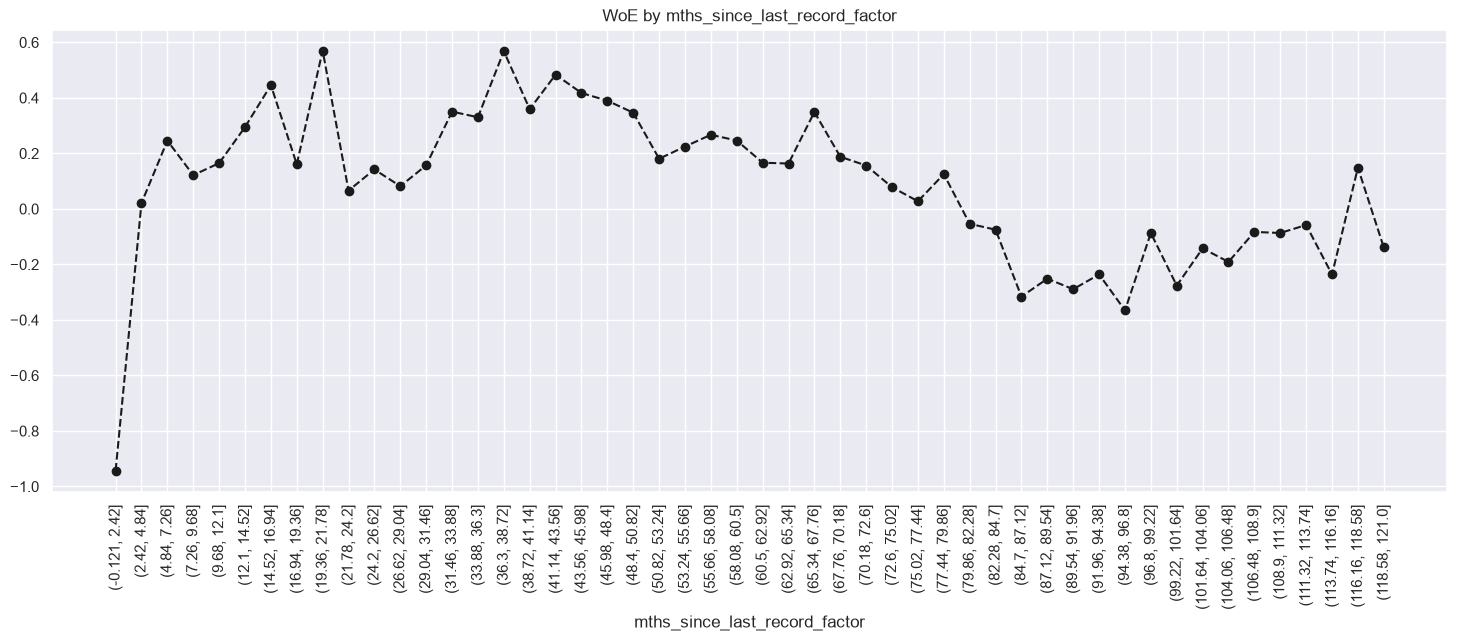

In [97]:
plot_by_woe(df_sincelastrec_temp, 90)

In [98]:
# slightly different from the course 
# <=2.42, 2.42-19.36, 19.36-31.46, 31.46-50.82, 50.82-79.86, >79.86
df_input_prep['mths_since_lst_missing'] = np.where((df_input_prep['mths_since_last_record'].isnull()),1,0)
df_input_prep['mths_since_lst_<=2.42'] =np.where((df_input_prep['mths_since_last_record']>=0)&(df_input_prep['mths_since_last_record'] <= 2.42), 1, 0)
df_input_prep['mths_since_lst_2.42-19.36'] =np.where((df_input_prep['mths_since_last_record'] > 2.42) & (df_input_prep['mths_since_last_record'] <= 19.36), 1, 0)
df_input_prep['mths_since_lst_19.36-31.46'] =np.where((df_input_prep['mths_since_last_record'] > 2.42) & (df_input_prep['mths_since_last_record'] <= 31.46), 1, 0)
df_input_prep['mths_since_lst_31.46-50.82'] =np.where((df_input_prep['mths_since_last_record'] > 31.46) & (df_input_prep['mths_since_last_record'] <= 50.82), 1, 0)
df_input_prep['mths_since_lst_50.82-79.86'] =np.where((df_input_prep['mths_since_last_record'] > 50.82) & (df_input_prep['mths_since_last_record'] <= 79.86), 1, 0)
df_input_prep['mths_since_lst_>79.86'] = np.where(df_input_prep['mths_since_last_record'] > 79.86, 1, 0)


/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2134846294.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_lst_missing'] = np.where((df_input_prep['mths_since_last_record'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29294/2134846294.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_lst_<=2.42'] =np.where((df_input_prep['mths_since_last_record']>=0)&(df_input_prep['mths_since_last_record'] <= 2.42), 1, 0)
/var/folders/c5/wvvv

In [101]:
df_input_prep.to_pickle('/Users/eileending/Downloads/loan_data_input_train.pkl')